In [ ]:
pip install requests beautifulsoup4

  Using cached requests-2.33.1-py3-none-any.whl.metadata (4.8 kB)
  Using cached beautifulsoup4-4.14.3-py3-none-any.whl.metadata (3.8 kB)
     ---------------------------------------- 0.0/41.7 kB ? eta -:--:--
     --------- ------------------------------ 10.2/41.7 kB ? eta -:--:--
     ------------------ ------------------- 20.5/41.7 kB 320.0 kB/s eta 0:00:01
     --------------------------- ---------- 30.7/41.7 kB 325.1 kB/s eta 0:00:01
     -------------------------------------- 41.7/41.7 kB 286.4 kB/s eta 0:00:00
  Using cached urllib3-2.6.3-py3-none-any.whl.metadata (6.9 kB)
  Using cached certifi-2026.2.25-py3-none-any.whl.metadata (2.5 kB)
  Using cached soupsieve-2.8.3-py3-none-any.whl.metadata (4.6 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
Using cached requests-2.33.1-py3-none-any.whl (64 kB)
Using cached beautifulsoup4-4.14.3-py3-none-any.whl (107 kB)
Using cached certifi-2026.2.25-py3-none-any.whl (153 kB)
   -----------------------------


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\manas\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [2]:
import requests
from bs4 import BeautifulSoup
import os

In [ ]:
# base_url = "https://media.talkbank.org/childes/Clinical-Eng/ENNI/SLI/A/"

# # Create a folder to save the files
# os.makedirs("ENNI_SLI_A", exist_ok=True)

# # Get the directory listing
# r = requests.get(base_url)
# # soup = BeautifulSoup(r.text, "html.parser")
# print("Status code:", r.status_code)
# print("\nPage content preview:")
# print(r.text[:2000])

# soup = BeautifulSoup(r.text, "html.parser")
# all_links = soup.find_all("a")
# for link in all_links:
#     print(link.get("href"))

# # Loop through all links and download files
# for link in soup.find_all("a"):
#     href = link.get("href")
#     if href and not href.startswith("?") and not href.startswith("/"):
#         file_url = base_url + href
#         save_path = os.path.join("ENNI_SLI_A", href)
#         print(f"Downloading {href}...")
#         response = requests.get(file_url)
#         with open(save_path, "wb") as f:
#             f.write(response.content)

# print("\n✅ All files downloaded to the 'ENNI_SLI_A' folder!")

Status code: 200

Page content preview:
<html>
				<body>
				<script type="module">
					import { initAuthModals } from 'https://sla2.talkbank.org:443/authUI/authModals.js';
				 	initAuthModals('https://sla2.talkbank.org:443', ()=>{window.location.reload(true)}, ()=>{window.location.reload(true)}, 'authModals', true);
				</script>
				</body>
				</html>
Total links found: 0


✅ All files downloaded to the 'ENNI_SLI_A' folder!


In [1]:
# print(os.getcwd())

In [2]:
#  Parse the .cha file to extract CHI timestamps
import re

def parse_cha(filepath):
    segments = []
    with open(filepath, 'r') as f:
        for line in f:
            if line.startswith('*CHI:'):
                # Finding timestamps like 7215_7834
                match = re.search(r'(\d+)_(\d+)', line)
                if match:
                    start_ms = int(match.group(1))
                    end_ms   = int(match.group(2))
                    text = re.sub(r'\d+_\d+', '', line[5:]).strip()
                    segments.append({
                        'start': start_ms / 1000, 
                        'end':   end_ms   / 1000,
                        'text':  text
                    })
    return segments

In [3]:
pip install pydub

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
pip install audioop-lts

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
pip install pydub

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
# Slice the audio into CHI-only segments
from pydub import AudioSegment
import os

def extract_child_audio(mp3_path, segments, out_dir="chi_segments"):
    os.makedirs(out_dir, exist_ok=True)
    audio = AudioSegment.from_mp3(mp3_path)
    
    for i, seg in enumerate(segments):
        start_ms = int(seg['start'] * 1000)
        end_ms   = int(seg['end']   * 1000)
        chunk = audio[start_ms:end_ms]
        out_path = f"{out_dir}/chi_{i:03d}.wav"
        chunk.export(out_path, format="wav")
        print(f"Saved: {out_path} | {seg['text']}")

In [8]:
pip install librosa

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
# Audio Cleaning (per segment)
import noisereduce as nr
import soundfile as sf
import librosa

def clean_audio(wav_path, out_path):
    y, sr = librosa.load(wav_path, sr=16000)  # resample to 16kHz (standard for speech)
    
    # 1. Noise reduction (estimates noise from signal)
    y_clean = nr.reduce_noise(y=y, sr=sr)
    
    # 2. Normalize amplitude
    y_norm = librosa.util.normalize(y_clean)
    
    sf.write(out_path, y_norm, sr)

c:\Users\manas\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Feature Extraction

1 — Acoustic Features (MFCC + Mel)


── SLI/A  (29 children) ──
  [OK]  413      58 utterances
  [OK]  444      68 utterances
  [OK]  479      69 utterances
  [OK]  529      77 utterances
  [OK]  568      57 utterances
  [OK]  570      71 utterances
  [OK]  572     165 utterances
  [OK]  574      83 utterances
  [OK]  607      88 utterances
  [OK]  609     133 utterances
  [OK]  617      83 utterances
  [OK]  625      73 utterances
  [OK]  678      74 utterances
  [OK]  717      75 utterances
  [OK]  721      82 utterances
  [OK]  725     201 utterances
  [OK]  729     134 utterances
  [OK]  733      66 utterances
  [OK]  777      58 utterances
  [OK]  817      69 utterances
  [OK]  821      71 utterances
  [OK]  825      72 utterances
  [OK]  829      66 utterances
  [OK]  871      71 utterances
  [OK]  878      47 utterances
  [OK]  880     112 utterances
  [OK]  922     178 utterances
  [OK]  926      83 utterances
  [OK]  973      63 utterances

── SLI/B  (37 children) ──
  [OK]  427      59 utterances
  [OK]  480   

C:\Users\manas\AppData\Local\Temp\ipykernel_2316\1435193686.py:123: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([sli_vals, td_vals],
C:\Users\manas\AppData\Local\Temp\ipykernel_2316\1435193686.py:123: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([sli_vals, td_vals],
C:\Users\manas\AppData\Local\Temp\ipykernel_2316\1435193686.py:123: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([sli_vals, td_vals],
C:\Users\manas\AppData\Local\Temp\ipykernel_2316\1435193686.py:123: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; 

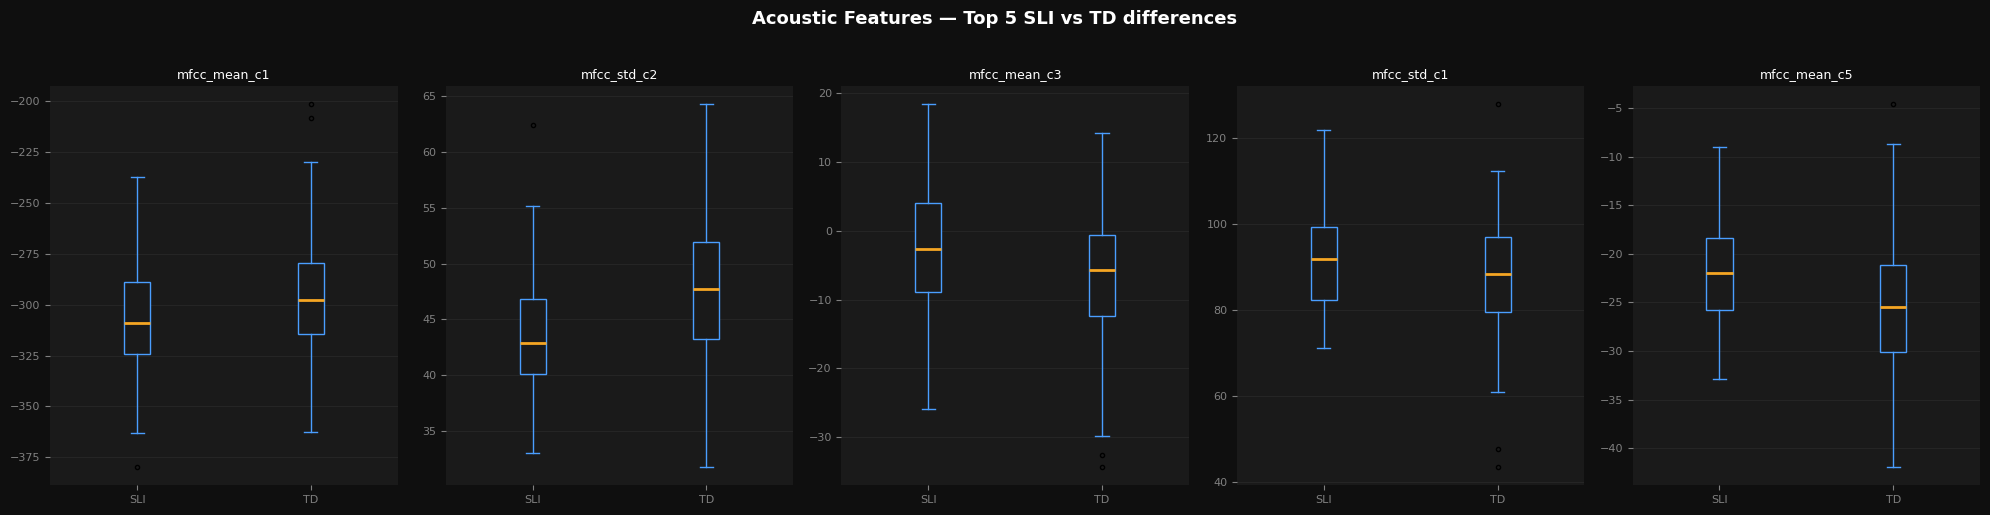

Plot saved → C:\CUNY\SPRING 2026\Speech and Audio Learning\Final_Project_SpeechLanguageImpairment\CHI_extracted\features\plots\acoustic_top5.png


In [ ]:
import os
import re
import pickle
import numpy as np
import librosa
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from sklearn.preprocessing import StandardScaler

# ── Config ────────────────────────────────────────────────────────────────────
BASE_DIR        = Path(r"C:\CUNY\SPRING 2026\Speech and Audio Learning\Final_Project_SpeechLanguageImpairment")
CLEANED_UTT_DIR = BASE_DIR / "CHI_extracted" / "utterances_cleaned"
FEATURES_DIR    = BASE_DIR / "CHI_extracted" / "features"
PLOTS_DIR       = FEATURES_DIR / "plots"
FEATURES_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

GROUPS  = ["SLI", "TD"]
SUBSETS = ["A", "B"]
SR      = 16000
N_MFCC  = 13
N_MELS  = 64
N_FFT   = 1024
HOP_LEN = 512

# ── Feature extraction per utterance ─────────────────────────────────────────
def extract_acoustic(wav_path):
    y, _ = librosa.load(str(wav_path), sr=SR, mono=True)
    if len(y) < SR * 0.1:
        return None

    mfcc = librosa.feature.mfcc(y=y, sr=SR, n_mfcc=N_MFCC,
                                  n_fft=N_FFT, hop_length=HOP_LEN)

    # delta requires width >= 3, odd, and <= n_frames
    # short utterances can have very few frames so we calculate dynamically
    n_frames = mfcc.shape[1]
    if n_frames < 3:
        return None                          # too short for any delta — skip

    # largest odd number <= n_frames, capped at 9 (librosa default)
    delta_width = min(9, n_frames if n_frames % 2 == 1 else n_frames - 1)

    mfcc_delta  = librosa.feature.delta(mfcc, width=delta_width)
    mfcc_delta2 = librosa.feature.delta(mfcc, width=delta_width, order=2)

    mel     = librosa.feature.melspectrogram(y=y, sr=SR, n_mels=N_MELS,
                                              n_fft=N_FFT, hop_length=HOP_LEN)
    log_mel = librosa.power_to_db(mel, ref=np.max)

    def ms(x): return np.concatenate([x.mean(axis=1), x.std(axis=1)])

    return np.concatenate([ms(mfcc), ms(mfcc_delta), ms(mfcc_delta2), ms(log_mel)])
    # 26 + 26 + 26 + 128 = 206 features

# ── Build feature matrix ──────────────────────────────────────────────────────
X_acoustic, y_labels, meta = [], [], []

FEATURE_NAMES = (
    [f"mfcc_mean_c{i+1}"       for i in range(N_MFCC)] +
    [f"mfcc_std_c{i+1}"        for i in range(N_MFCC)] +
    [f"mfcc_d_mean_c{i+1}"     for i in range(N_MFCC)] +
    [f"mfcc_d_std_c{i+1}"      for i in range(N_MFCC)] +
    [f"mfcc_dd_mean_c{i+1}"    for i in range(N_MFCC)] +
    [f"mfcc_dd_std_c{i+1}"     for i in range(N_MFCC)] +
    [f"logmel_mean_b{i+1}"     for i in range(N_MELS)] +
    [f"logmel_std_b{i+1}"      for i in range(N_MELS)]
)

for group in GROUPS:
    label = 0 if group == "SLI" else 1
    for subset in SUBSETS:
        folder = CLEANED_UTT_DIR / group / subset
        if not folder.exists():
            print(f"  [SKIP] {group}/{subset}")
            continue

        child_files = {}
        for wav in sorted(folder.glob("*.wav")):
            m = re.match(r"^(\d+)_chi_", wav.name)
            if m:
                child_files.setdefault(m.group(1), []).append(wav)

        print(f"\n── {group}/{subset}  ({len(child_files)} children) ──")
        for cid, wavs in sorted(child_files.items()):
            vecs = [v for wav in wavs if (v := extract_acoustic(wav)) is not None]
            if not vecs:
                continue
            X_acoustic.append(np.mean(vecs, axis=0))
            y_labels.append(label)
            meta.append({"id": cid, "group": group, "subset": subset, "label": label})
            # print(f"  [OK]  {cid:<6}  {len(vecs):>3} utterances")

X_acoustic = np.array(X_acoustic)   # (n_children, 206)
y_labels   = np.array(y_labels)

print(f"\nAcoustic matrix : {X_acoustic.shape}")
print(f"SLI={np.sum(y_labels==0)}  TD={np.sum(y_labels==1)}")

# ── Save ──────────────────────────────────────────────────────────────────────
np.save(FEATURES_DIR / "X_acoustic_raw.npy",  X_acoustic)
np.save(FEATURES_DIR / "y_labels.npy",        y_labels)
with open(FEATURES_DIR / "meta.pkl",           "wb") as f: pickle.dump(meta, f)
with open(FEATURES_DIR / "acoustic_feature_names.pkl", "wb") as f:
    pickle.dump(FEATURE_NAMES, f)
print(f"Saved → {FEATURES_DIR}")

# ── Visualization — top 5 most discriminative features ───────────────────────
sli_mean = X_acoustic[y_labels == 0].mean(axis=0)
td_mean  = X_acoustic[y_labels == 1].mean(axis=0)
diff     = np.abs(sli_mean - td_mean)
top5_idx = np.argsort(diff)[::-1][:5]
top5_names = [FEATURE_NAMES[i] for i in top5_idx]

fig, axes = plt.subplots(1, 5, figsize=(20, 5), facecolor="#0f0f0f")
fig.suptitle("Acoustic Features — Top 5 SLI vs TD differences",
             color="white", fontsize=13, fontweight="bold", y=1.02)

for ax, idx, name in zip(axes, top5_idx, top5_names):
    sli_vals = X_acoustic[y_labels == 0, idx]
    td_vals  = X_acoustic[y_labels == 1, idx]
    ax.boxplot([sli_vals, td_vals],
               labels=["SLI", "TD"],
               patch_artist=True,
               boxprops=dict(facecolor="#1a1a1a", color="#4a9eff"),
               medianprops=dict(color="#f5a623", linewidth=2),
               whiskerprops=dict(color="#4a9eff"),
               capprops=dict(color="#4a9eff"),
               flierprops=dict(marker="o", color="#e05c5c", markersize=3))
    ax.set_facecolor("#1a1a1a")
    ax.set_title(name, color="white", fontsize=9, pad=6)
    ax.tick_params(colors="grey", labelsize=8)
    ax.yaxis.grid(True, color="#2a2a2a", linewidth=0.5)
    for sp in ax.spines.values(): sp.set_visible(False)

fig.patch.set_facecolor("#0f0f0f")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "acoustic_top5.png", dpi=150,
            bbox_inches="tight", facecolor="#0f0f0f")
plt.show()
print(f"Plot saved → {PLOTS_DIR / 'acoustic_top5.png'}")

  Plotting SLI/A child 413 ← 413_chi_054.wav
  Plotting SLI/A child 444 ← 444_chi_008.wav
  Plotting SLI/A child 479 ← 479_chi_046.wav
  Plotting SLI/A child 529 ← 529_chi_050.wav
  Plotting SLI/A child 568 ← 568_chi_005.wav


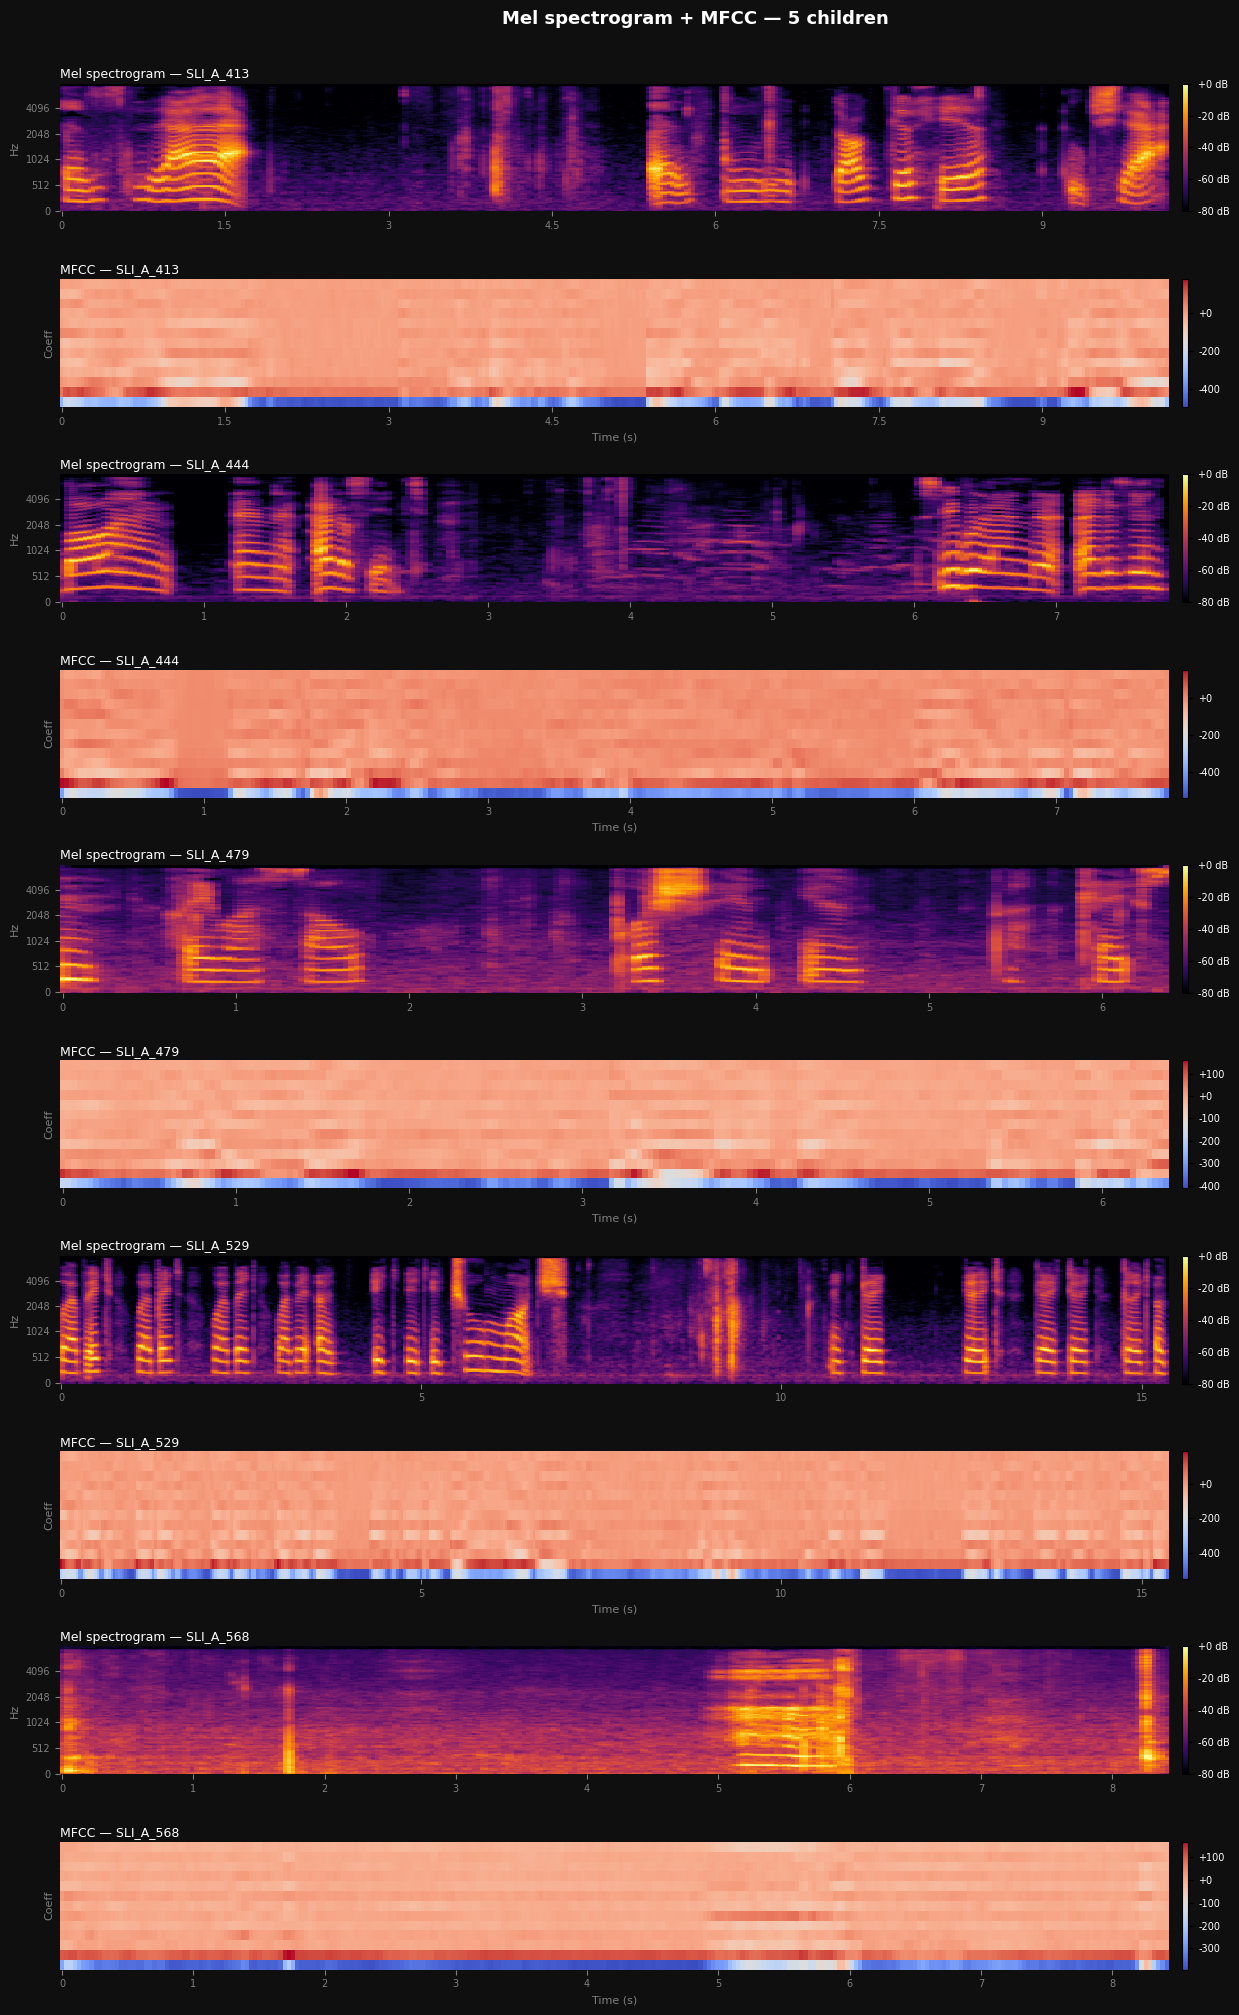


Saved → C:\CUNY\SPRING 2026\Speech and Audio Learning\Final_Project_SpeechLanguageImpairment\CHI_extracted\features\plots\mel_mfcc_5_children.png


In [5]:
import re
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from pathlib import Path

# ── Config ────────────────────────────────────────────────────────────────────
BASE_DIR        = Path(r"C:\CUNY\SPRING 2026\Speech and Audio Learning\Final_Project_SpeechLanguageImpairment")
CLEANED_UTT_DIR = BASE_DIR / "CHI_extracted" / "utterances_cleaned"
PLOTS_DIR       = BASE_DIR / "CHI_extracted" / "features" / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

SR      = 16000
N_MFCC  = 13
N_MELS  = 128        # higher mel bins = richer visual like your reference
N_FFT   = 2048
HOP_LEN = 512

N_CHILDREN  = 5      # how many children to plot
GROUPS      = ["SLI", "TD"]
SUBSETS     = ["A", "B"]

# ── Collect one merged wav per child (use longest utterance for best visual) ──
def get_child_examples(n=5):
    """
    Returns list of dicts with keys: cid, group, wav_path
    Picks children from both SLI and TD so comparison is meaningful.
    """
    examples = []
    for group in GROUPS:
        for subset in SUBSETS:
            folder = CLEANED_UTT_DIR / group / subset
            if not folder.exists():
                continue

            # Group by child id
            child_files = {}
            for wav in sorted(folder.glob("*.wav")):
                m = re.match(r"^(\d+)_chi_", wav.name)
                if m:
                    child_files.setdefault(m.group(1), []).append(wav)

            for cid, wavs in sorted(child_files.items()):
                if len(examples) >= n:
                    return examples
                # Pick the longest utterance for this child — best visual
                longest = max(wavs, key=lambda w: w.stat().st_size)
                examples.append({
                    "cid":      cid,
                    "group":    group,
                    "subset":   subset,
                    "wav_path": longest
                })
    return examples

# ── Plot Mel + MFCC stacked for one child ────────────────────────────────────
def plot_child(child, fig, row):
    y, _ = librosa.load(str(child["wav_path"]), sr=SR, mono=True)
    title_stem = f"{child['group']}_{child['subset']}_{child['cid']}"

    # Mel spectrogram (power → dB)
    mel     = librosa.feature.melspectrogram(y=y, sr=SR, n_mels=N_MELS,
                                              n_fft=N_FFT, hop_length=HOP_LEN)
    log_mel = librosa.power_to_db(mel, ref=np.max)

    # MFCC
    mfcc = librosa.feature.mfcc(y=y, sr=SR, n_mfcc=N_MFCC,
                                  n_fft=N_FFT, hop_length=HOP_LEN)

    # ── Mel spectrogram axis ──────────────────────────────────────────────────
    ax_mel = fig.add_subplot(N_CHILDREN * 2, 1, row * 2 + 1)
    img1   = librosa.display.specshow(log_mel, sr=SR, hop_length=HOP_LEN,
                                       x_axis="time", y_axis="mel",
                                       ax=ax_mel, cmap="inferno")
    fig.colorbar(img1, ax=ax_mel, format="%+.0f dB", pad=0.01
                 ).ax.tick_params(labelcolor="white", labelsize=7)
    ax_mel.set_title(f"Mel spectrogram — {title_stem}",
                     color="white", fontsize=9, pad=4, loc="left")
    ax_mel.set_ylabel("Hz", color="grey", fontsize=8)
    ax_mel.set_xlabel("")
    ax_mel.tick_params(colors="grey", labelsize=7)
    ax_mel.set_facecolor("#0f0f0f")
    for sp in ax_mel.spines.values(): sp.set_visible(False)

    # ── MFCC axis ─────────────────────────────────────────────────────────────
    ax_mfcc = fig.add_subplot(N_CHILDREN * 2, 1, row * 2 + 2)
    img2    = librosa.display.specshow(mfcc, sr=SR, hop_length=HOP_LEN,
                                        x_axis="time",
                                        ax=ax_mfcc, cmap="coolwarm")
    fig.colorbar(img2, ax=ax_mfcc, format="%+.0f", pad=0.01
                 ).ax.tick_params(labelcolor="white", labelsize=7)
    ax_mfcc.set_title(f"MFCC — {title_stem}",
                      color="white", fontsize=9, pad=4, loc="left")
    ax_mfcc.set_ylabel("Coeff", color="grey", fontsize=8)
    ax_mfcc.set_xlabel("Time (s)", color="grey", fontsize=8)
    ax_mfcc.tick_params(colors="grey", labelsize=7)
    ax_mfcc.set_facecolor("#0f0f0f")
    for sp in ax_mfcc.spines.values(): sp.set_visible(False)

# ── Build figure ──────────────────────────────────────────────────────────────
examples = get_child_examples(n=N_CHILDREN)

if not examples:
    print("[ERR] No utterance files found — run audio extraction first")
else:
    fig = plt.figure(figsize=(14, N_CHILDREN * 4), facecolor="#0f0f0f")
    fig.suptitle(f"Mel spectrogram + MFCC — {N_CHILDREN} children",
                 color="white", fontsize=13, fontweight="bold", y=1.005)

    for row, child in enumerate(examples):
        print(f"  Plotting {child['group']}/{child['subset']} child {child['cid']} "
              f"← {child['wav_path'].name}")
        plot_child(child, fig, row)

    plt.tight_layout(h_pad=1.2)
    out = PLOTS_DIR / f"mel_mfcc_{N_CHILDREN}_children.png"
    plt.savefig(str(out), dpi=150, bbox_inches="tight", facecolor="#0f0f0f")
    plt.show()
    print(f"\nSaved → {out}")

2 — Prosodic & Voice Quality Features

In [1]:
import sys
!{sys.executable} -m pip install praat-parselmouth

   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   ------------ --------------------------- 2.9/9.1 MB 26.3 MB/s eta 0:00:01
   ---------------------------------------- 9.1/9.1 MB 37.0 MB/s  0:00:00



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



── SLI/A  (29 children) ──


c:\Users\manas\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  [OK]  413      55 utterances
  [OK]  444      68 utterances
  [OK]  479      67 utterances
  [OK]  529      75 utterances
  [OK]  568      57 utterances
  [OK]  570      71 utterances
  [OK]  572     165 utterances
  [OK]  574      82 utterances
  [OK]  607      88 utterances
  [OK]  609     131 utterances
  [OK]  617      82 utterances
  [OK]  625      73 utterances
  [OK]  678      74 utterances
  [OK]  717      74 utterances
  [OK]  721      81 utterances
  [OK]  725     201 utterances
  [OK]  729     132 utterances
  [OK]  733      65 utterances
  [OK]  777      58 utterances
  [OK]  817      69 utterances
  [OK]  821      70 utterances
  [OK]  825      72 utterances
  [OK]  829      65 utterances
  [OK]  871      70 utterances
  [OK]  878      47 utterances
  [OK]  880     112 utterances
  [OK]  922     177 utterances
  [OK]  926      83 utterances
  [OK]  973      63 utterances

── SLI/B  (37 children) ──
  [OK]  427      58 utterances
  [OK]  480     140 utterances
  [OK]  527

c:\Users\manas\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1760
  warnings.warn(


  [OK]  406     108 utterances
  [OK]  409      66 utterances
  [OK]  410      61 utterances
  [OK]  414      78 utterances
  [OK]  417     124 utterances
  [OK]  418      98 utterances
  [OK]  421     196 utterances
  [OK]  425     116 utterances
  [OK]  429      65 utterances
  [OK]  441      63 utterances
  [OK]  448      80 utterances
  [OK]  452      48 utterances
  [OK]  456      61 utterances
  [OK]  457      88 utterances
  [OK]  460      67 utterances
  [OK]  464      61 utterances
  [OK]  468      64 utterances
  [OK]  471      94 utterances
  [OK]  501      89 utterances
  [OK]  502      80 utterances
  [OK]  505      62 utterances
  [OK]  506      77 utterances
  [OK]  509      86 utterances
  [OK]  510      64 utterances
  [OK]  513      69 utterances
  [OK]  514      77 utterances
  [OK]  517     154 utterances
  [OK]  518      78 utterances
  [OK]  522      63 utterances
  [OK]  526      96 utterances
  [OK]  530      82 utterances
  [OK]  538      64 utterances
  [OK]  

C:\Users\manas\AppData\Local\Temp\ipykernel_7448\3344047672.py:153: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([sli_vals, td_vals],
C:\Users\manas\AppData\Local\Temp\ipykernel_7448\3344047672.py:153: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([sli_vals, td_vals],
C:\Users\manas\AppData\Local\Temp\ipykernel_7448\3344047672.py:153: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([sli_vals, td_vals],
C:\Users\manas\AppData\Local\Temp\ipykernel_7448\3344047672.py:153: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; 

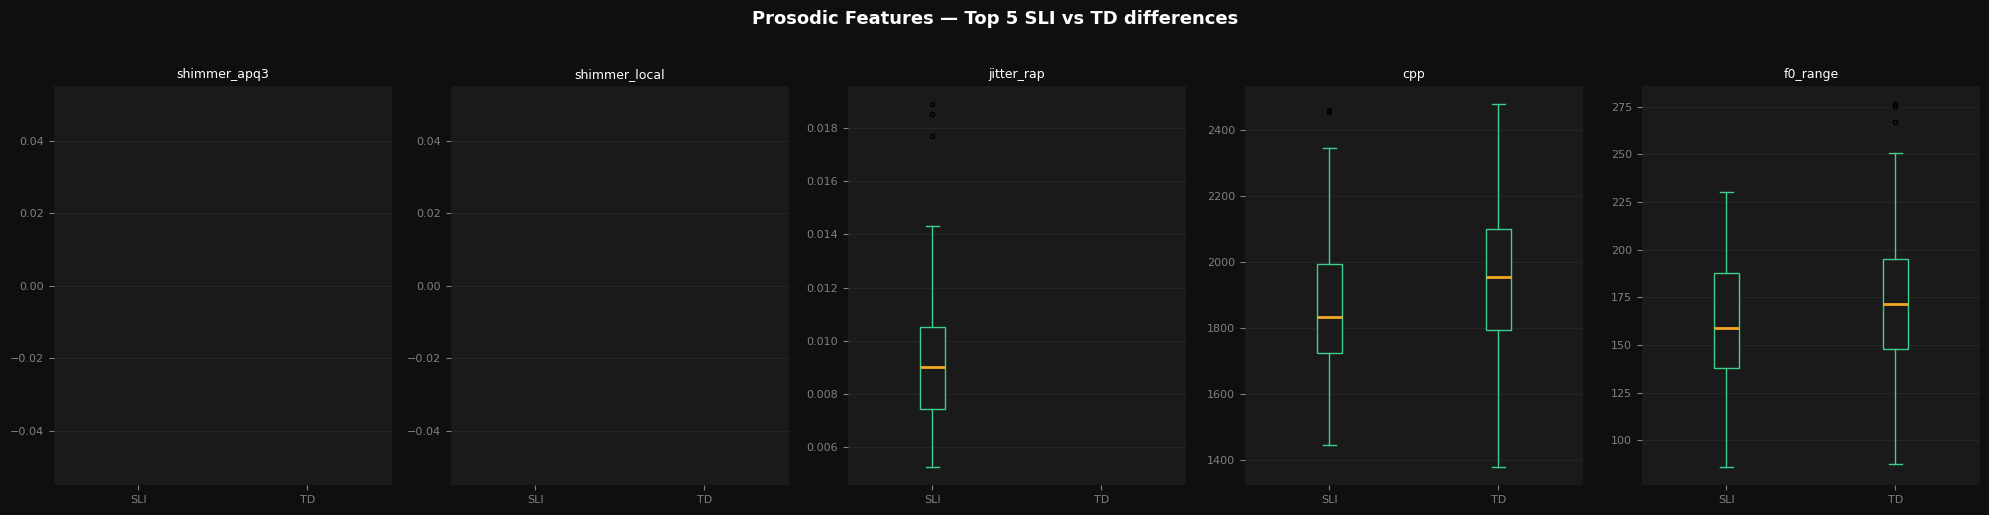

Plot saved → C:\CUNY\SPRING 2026\Speech and Audio Learning\Final_Project_SpeechLanguageImpairment\CHI_extracted\features\plots\prosodic_top5.png


In [3]:
import os
import re
import pickle
import numpy as np
import librosa
import parselmouth
import matplotlib.pyplot as plt
from parselmouth.praat import call
from pathlib import Path

# ── install parselmouth if missing ────────────────────────────────────────────
try:
    import parselmouth
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "praat-parselmouth"],
                   check=True)
    import parselmouth
    from parselmouth.praat import call

# ── Config ────────────────────────────────────────────────────────────────────
BASE_DIR        = Path(r"C:\CUNY\SPRING 2026\Speech and Audio Learning\Final_Project_SpeechLanguageImpairment")
CLEANED_UTT_DIR = BASE_DIR / "CHI_extracted" / "utterances_cleaned"
FEATURES_DIR    = BASE_DIR / "CHI_extracted" / "features"
PLOTS_DIR       = FEATURES_DIR / "plots"
FEATURES_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

GROUPS  = ["SLI", "TD"]
SUBSETS = ["A", "B"]
SR      = 16000

FEATURE_NAMES_PROSODIC = [
    "f0_mean", "f0_std", "f0_min", "f0_max", "f0_range",   # pitch
    "jitter_local", "jitter_rap",                           # jitter
    "shimmer_local", "shimmer_apq3",                        # shimmer
    "hnr",                                                   # harmonics-to-noise
    "cpp"                                                    # cepstral peak prominence
]

# ── Feature extraction per utterance ─────────────────────────────────────────
def extract_prosodic(wav_path):
    try:
        snd   = parselmouth.Sound(str(wav_path))
        dur   = snd.duration
        if dur < 0.1:
            return None

        # ── Pitch (F0) ────────────────────────────────────────────────────────
        # Child speech F0 range: 150–500 Hz
        pitch      = snd.to_pitch(pitch_floor=150.0, pitch_ceiling=500.0)
        f0_vals    = pitch.selected_array["frequency"]
        f0_voiced  = f0_vals[f0_vals > 0]

        if len(f0_voiced) < 3:
            return None

        f0_mean  = float(np.mean(f0_voiced))
        f0_std   = float(np.std(f0_voiced))
        f0_min   = float(np.min(f0_voiced))
        f0_max   = float(np.max(f0_voiced))
        f0_range = f0_max - f0_min

        # ── Jitter & Shimmer (via PointProcess) ───────────────────────────────
        pp      = call([snd, pitch], "To PointProcess (cc)")
        jitter_local = call(pp, "Get jitter (local)",
                            0, 0, 0.0001, 0.02, 1.3)
        jitter_rap   = call(pp, "Get jitter (rap)",
                            0, 0, 0.0001, 0.02, 1.3)
        shimmer_local = call([snd, pp], "Get shimmer (local)",
                             0, 0, 0.0001, 0.02, 1.3, 1.6)
        shimmer_apq3  = call([snd, pp], "Get shimmer (apq3)",
                             0, 0, 0.0001, 0.02, 1.3, 1.6)

        # ── Harmonics-to-Noise Ratio ──────────────────────────────────────────
        harmonicity = call(snd, "To Harmonicity (cc)", 0.01, 150.0, 0.1, 1.0)
        hnr         = call(harmonicity, "Get mean", 0, 0)
        if np.isnan(hnr): hnr = 0.0

        # ── Cepstral Peak Prominence (CPP) ────────────────────────────────────
        # Proxy via spectral centroid — full CPP needs PowerCepstrogram
        # which requires Praat 6.x; using librosa fallback for compatibility
        y, _ = librosa.load(str(wav_path), sr=SR)
        cent  = librosa.feature.spectral_centroid(y=y, sr=SR)
        cpp   = float(np.mean(cent))

        return np.array([
            f0_mean, f0_std, f0_min, f0_max, f0_range,
            jitter_local, jitter_rap,
            shimmer_local, shimmer_apq3,
            hnr, cpp
        ], dtype=np.float32)

    except Exception as e:
        return None

# ── Build feature matrix ──────────────────────────────────────────────────────
X_prosodic, y_labels, meta = [], [], []

for group in GROUPS:
    label = 0 if group == "SLI" else 1
    for subset in SUBSETS:
        folder = CLEANED_UTT_DIR / group / subset
        if not folder.exists():
            print(f"  [SKIP] {group}/{subset}")
            continue

        child_files = {}
        for wav in sorted(folder.glob("*.wav")):
            m = re.match(r"^(\d+)_chi_", wav.name)
            if m:
                child_files.setdefault(m.group(1), []).append(wav)

        print(f"\n── {group}/{subset}  ({len(child_files)} children) ──")
        for cid, wavs in sorted(child_files.items()):
            vecs = [v for wav in wavs if (v := extract_prosodic(wav)) is not None]
            if not vecs:
                print(f"  [WARN] {cid} — no valid utterances")
                continue
            X_prosodic.append(np.mean(vecs, axis=0))
            y_labels.append(label)
            meta.append({"id": cid, "group": group, "subset": subset, "label": label})
            print(f"  [OK]  {cid:<6}  {len(vecs):>3} utterances")

X_prosodic = np.array(X_prosodic)
y_labels   = np.array(y_labels)

print(f"\nProsodic matrix : {X_prosodic.shape}")
print(f"SLI={np.sum(y_labels==0)}  TD={np.sum(y_labels==1)}")

# ── Save ──────────────────────────────────────────────────────────────────────
np.save(FEATURES_DIR / "X_prosodic_raw.npy", X_prosodic)
np.save(FEATURES_DIR / "y_labels.npy",       y_labels)
with open(FEATURES_DIR / "meta.pkl",          "wb") as f: pickle.dump(meta, f)
with open(FEATURES_DIR / "prosodic_feature_names.pkl", "wb") as f:
    pickle.dump(FEATURE_NAMES_PROSODIC, f)
print(f"Saved → {FEATURES_DIR}")

# ── Visualization — top 5 most discriminative features ───────────────────────
sli_mean = X_prosodic[y_labels == 0].mean(axis=0)
td_mean  = X_prosodic[y_labels == 1].mean(axis=0)
diff     = np.abs(sli_mean - td_mean)
top5_idx = np.argsort(diff)[::-1][:5]

fig, axes = plt.subplots(1, 5, figsize=(20, 5), facecolor="#0f0f0f")
fig.suptitle("Prosodic Features — Top 5 SLI vs TD differences",
             color="white", fontsize=13, fontweight="bold", y=1.02)

for ax, idx in zip(axes, top5_idx):
    name     = FEATURE_NAMES_PROSODIC[idx]
    sli_vals = X_prosodic[y_labels == 0, idx]
    td_vals  = X_prosodic[y_labels == 1, idx]
    ax.boxplot([sli_vals, td_vals],
               labels=["SLI", "TD"],
               patch_artist=True,
               boxprops=dict(facecolor="#1a1a1a", color="#3ecf8e"),
               medianprops=dict(color="#f5a623", linewidth=2),
               whiskerprops=dict(color="#3ecf8e"),
               capprops=dict(color="#3ecf8e"),
               flierprops=dict(marker="o", color="#e05c5c", markersize=3))
    ax.set_facecolor("#1a1a1a")
    ax.set_title(name, color="white", fontsize=9, pad=6)
    ax.tick_params(colors="grey", labelsize=8)
    ax.yaxis.grid(True, color="#2a2a2a", linewidth=0.5)
    for sp in ax.spines.values(): sp.set_visible(False)

fig.patch.set_facecolor("#0f0f0f")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "prosodic_top5.png", dpi=150,
            bbox_inches="tight", facecolor="#0f0f0f")
plt.show()
print(f"Plot saved → {PLOTS_DIR / 'prosodic_top5.png'}")

  Processing SLI/A child 413 ← 413_chi_054.wav
  Processing SLI/A child 444 ← 444_chi_008.wav
  Processing SLI/A child 479 ← 479_chi_046.wav


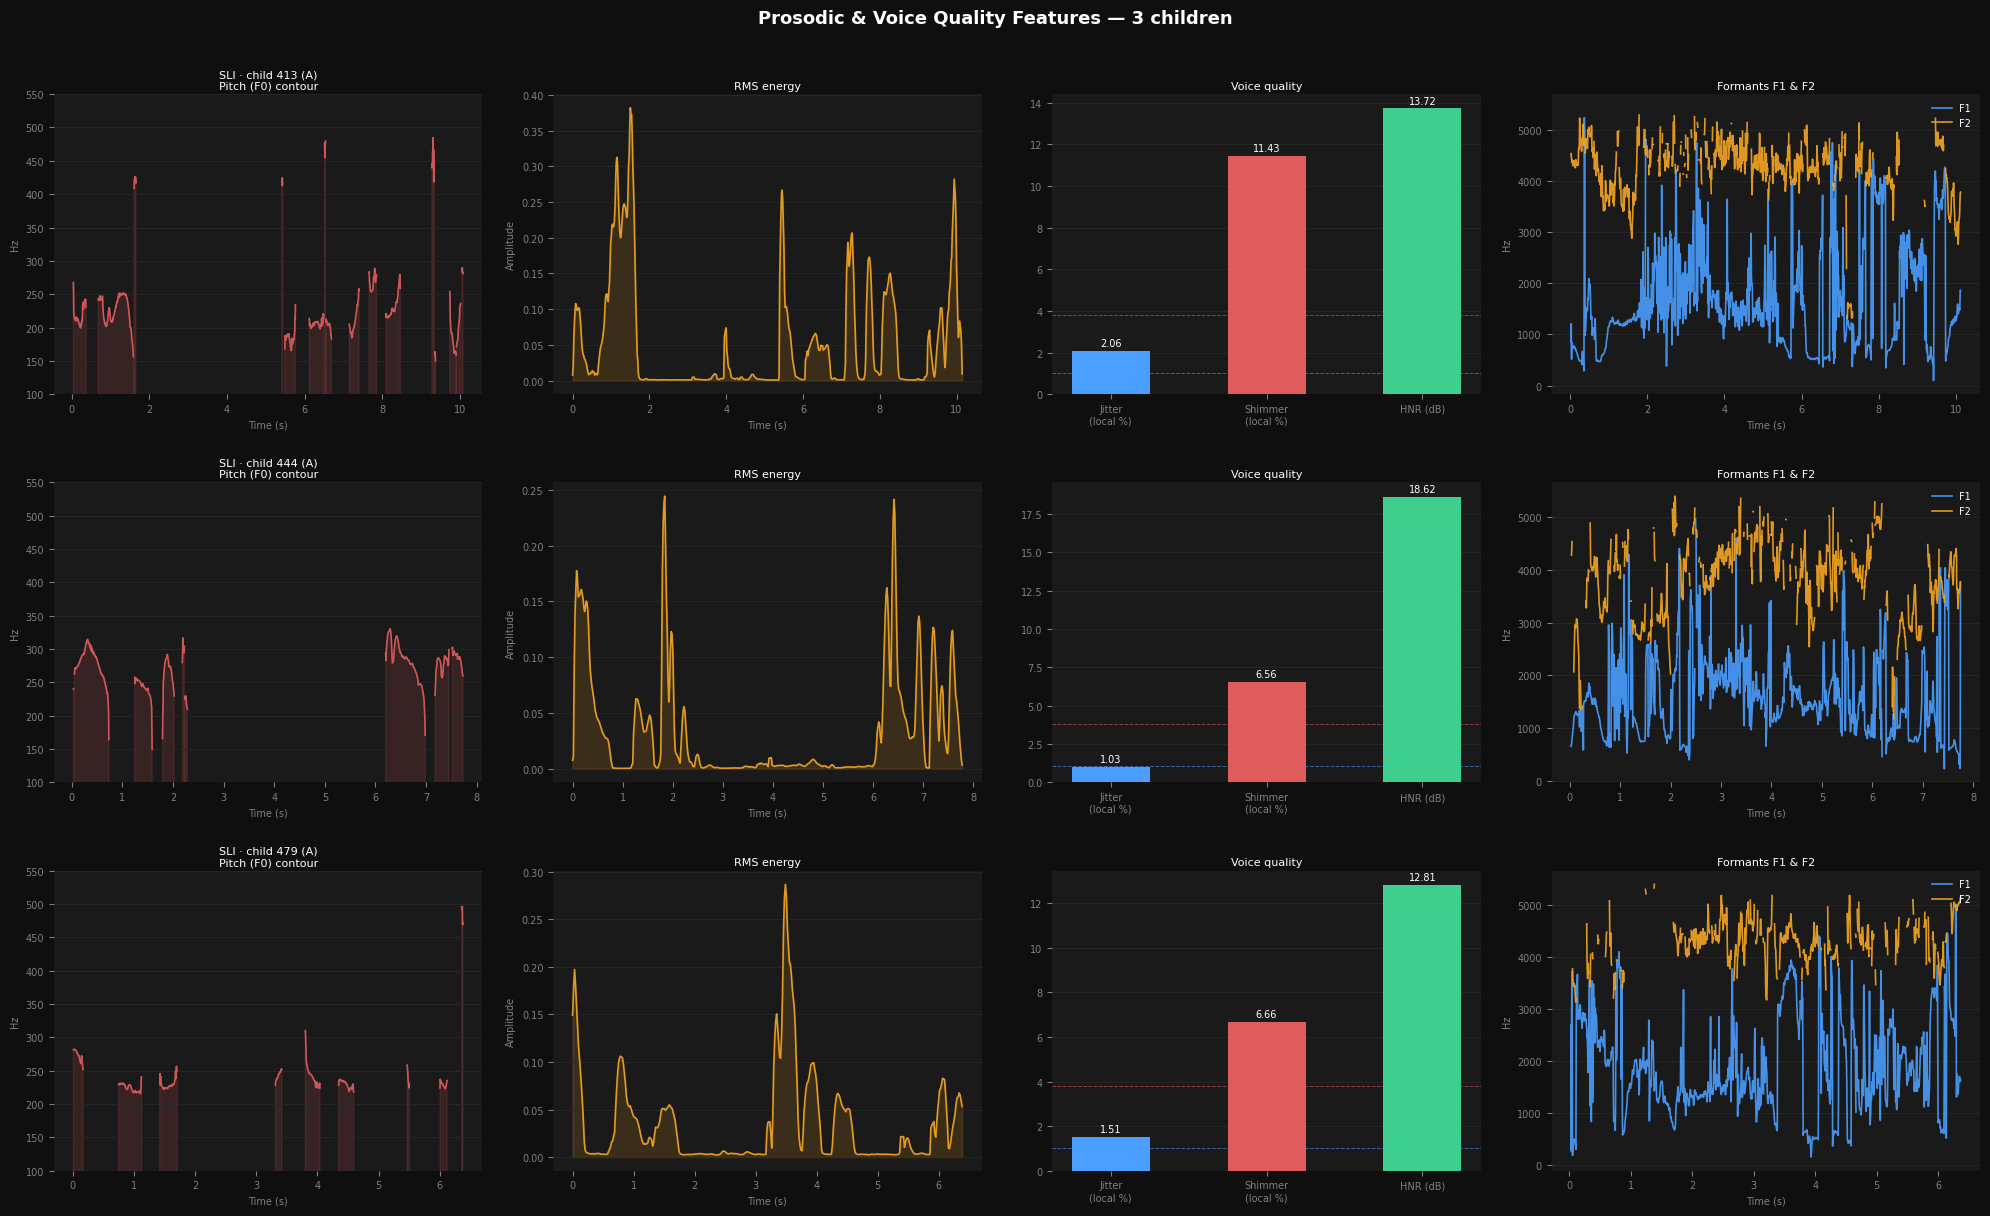


Saved → C:\CUNY\SPRING 2026\Speech and Audio Learning\Final_Project_SpeechLanguageImpairment\CHI_extracted\features\plots\prosodic_3_children.png


In [4]:
import re
import numpy as np
import librosa
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import parselmouth
from parselmouth.praat import call
from pathlib import Path

# ── Config ────────────────────────────────────────────────────────────────────
BASE_DIR        = Path(r"C:\CUNY\SPRING 2026\Speech and Audio Learning\Final_Project_SpeechLanguageImpairment")
CLEANED_UTT_DIR = BASE_DIR / "CHI_extracted" / "utterances_cleaned"
PLOTS_DIR       = BASE_DIR / "CHI_extracted" / "features" / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

SR         = 16000
N_CHILDREN = 3
GROUPS     = ["SLI", "TD"]
SUBSETS    = ["A", "B"]

# ── Collect longest utterance per child ───────────────────────────────────────
def get_child_examples(n=3):
    examples = []
    for group in GROUPS:
        for subset in SUBSETS:
            folder = CLEANED_UTT_DIR / group / subset
            if not folder.exists():
                continue
            child_files = {}
            for wav in sorted(folder.glob("*.wav")):
                m = re.match(r"^(\d+)_chi_", wav.name)
                if m:
                    child_files.setdefault(m.group(1), []).append(wav)
            for cid, wavs in sorted(child_files.items()):
                if len(examples) >= n:
                    return examples
                longest = max(wavs, key=lambda w: w.stat().st_size)
                examples.append({"cid": cid, "group": group,
                                  "subset": subset, "wav_path": longest})
    return examples

# ── Extract raw prosodic data for plotting (not just mean/std) ────────────────
def get_prosodic_data(wav_path):
    """
    Returns raw time-series data for visualization:
      - f0_times, f0_vals     : pitch contour over time
      - times, rms            : energy/loudness over time
      - jitter, shimmer, hnr  : scalar voice quality values
    """
    snd = parselmouth.Sound(str(wav_path))

    # ── Pitch contour ─────────────────────────────────────────────────────────
    pitch      = snd.to_pitch(pitch_floor=150.0, pitch_ceiling=500.0)
    f0_times   = pitch.xs()
    f0_vals    = pitch.selected_array["frequency"]
    f0_vals[f0_vals == 0] = np.nan        # unvoiced frames → NaN for clean plot

    # ── RMS energy over time ──────────────────────────────────────────────────
    y, _  = librosa.load(str(wav_path), sr=SR)
    rms   = librosa.feature.rms(y=y, frame_length=1024, hop_length=256)[0]
    times = librosa.frames_to_time(np.arange(len(rms)), sr=SR, hop_length=256)

    # ── Jitter & Shimmer (scalar) ─────────────────────────────────────────────
    pp             = call([snd, pitch], "To PointProcess (cc)")
    jitter_local   = call(pp, "Get jitter (local)",   0, 0, 0.0001, 0.02, 1.3)
    shimmer_local  = call([snd, pp], "Get shimmer (local)", 0, 0, 0.0001, 0.02, 1.3, 1.6)

    # ── HNR ──────────────────────────────────────────────────────────────────
    harmonicity = call(snd, "To Harmonicity (cc)", 0.01, 150.0, 0.1, 1.0)
    hnr         = call(harmonicity, "Get mean", 0, 0)
    if np.isnan(hnr): hnr = 0.0

    # ── Formants F1 + F2 over time ────────────────────────────────────────────
    formant      = snd.to_formant_burg(max_number_of_formants=2.0,
                                        maximum_formant=5500.0)
    f_times      = pitch.xs()
    f1_vals, f2_vals = [], []
    for t in f_times:
        f1 = call(formant, "Get value at time", 1, t, "Hertz", "Linear")
        f2 = call(formant, "Get value at time", 2, t, "Hertz", "Linear")
        f1_vals.append(f1 if not np.isnan(f1) else np.nan)
        f2_vals.append(f2 if not np.isnan(f2) else np.nan)

    return {
        "f0_times":  f0_times,
        "f0_vals":   f0_vals,
        "rms_times": times,
        "rms_vals":  rms,
        "jitter":    jitter_local,
        "shimmer":   shimmer_local,
        "hnr":       hnr,
        "f_times":   np.array(f_times),
        "f1_vals":   np.array(f1_vals),
        "f2_vals":   np.array(f2_vals),
    }

# ── Plot all prosodic features for one child ──────────────────────────────────
def plot_prosodic(child, data, fig, row_start):
    label  = child["group"]
    title  = f"{label} · child {child['cid']} ({child['subset']})"
    color  = "#e05c5c" if label == "SLI" else "#3ecf8e"

    # Row layout per child: 4 panels across
    # [0] F0 contour   [1] RMS energy   [2] Jitter/Shimmer/HNR bar   [3] F1/F2 formants

    # ── Panel 1: Pitch (F0) contour ───────────────────────────────────────────
    ax1 = fig.add_subplot(N_CHILDREN, 4, row_start + 1)
    ax1.plot(data["f0_times"], data["f0_vals"],
             color=color, linewidth=1.2, alpha=0.9)
    ax1.fill_between(data["f0_times"], data["f0_vals"],
                     alpha=0.15, color=color)
    ax1.set_title(f"{title}\nPitch (F0) contour", color="white",
                  fontsize=8, pad=4)
    ax1.set_xlabel("Time (s)", color="grey", fontsize=7)
    ax1.set_ylabel("Hz", color="grey", fontsize=7)
    ax1.tick_params(colors="grey", labelsize=7)
    ax1.set_facecolor("#1a1a1a")
    ax1.yaxis.grid(True, color="#2a2a2a", linewidth=0.5)
    ax1.set_ylim(100, 550)
    for sp in ax1.spines.values(): sp.set_visible(False)

    # ── Panel 2: RMS energy ───────────────────────────────────────────────────
    ax2 = fig.add_subplot(N_CHILDREN, 4, row_start + 2)
    ax2.plot(data["rms_times"], data["rms_vals"],
             color="#f5a623", linewidth=1.2, alpha=0.9)
    ax2.fill_between(data["rms_times"], data["rms_vals"],
                     alpha=0.15, color="#f5a623")
    ax2.set_title("RMS energy", color="white", fontsize=8, pad=4)
    ax2.set_xlabel("Time (s)", color="grey", fontsize=7)
    ax2.set_ylabel("Amplitude", color="grey", fontsize=7)
    ax2.tick_params(colors="grey", labelsize=7)
    ax2.set_facecolor("#1a1a1a")
    ax2.yaxis.grid(True, color="#2a2a2a", linewidth=0.5)
    for sp in ax2.spines.values(): sp.set_visible(False)

    # ── Panel 3: Jitter / Shimmer / HNR bar chart ─────────────────────────────
    ax3  = fig.add_subplot(N_CHILDREN, 4, row_start + 3)
    metrics = ["Jitter\n(local %)", "Shimmer\n(local %)", "HNR (dB)"]
    values  = [
        data["jitter"]  * 100,
        data["shimmer"] * 100,
        data["hnr"]
    ]
    bar_colors = ["#4a9eff", "#e05c5c", "#3ecf8e"]
    bars = ax3.bar(metrics, values, color=bar_colors,
                   width=0.5, zorder=3)
    ax3.bar_label(bars, fmt="%.2f", label_type="edge",
                  fontsize=7, color="white", padding=2)
    ax3.set_title("Voice quality", color="white", fontsize=8, pad=4)
    ax3.tick_params(colors="grey", labelsize=7)
    ax3.set_facecolor("#1a1a1a")
    ax3.yaxis.grid(True, color="#2a2a2a", linewidth=0.5, zorder=0)
    # Reference lines for clinical thresholds
    ax3.axhline(1.04, color="#4a9eff",  linewidth=0.7,
                linestyle="--", alpha=0.6, label="jitter thresh")
    ax3.axhline(3.81, color="#e05c5c",  linewidth=0.7,
                linestyle="--", alpha=0.6, label="shimmer thresh")
    for sp in ax3.spines.values(): sp.set_visible(False)

    # ── Panel 4: F1 / F2 formants over time ───────────────────────────────────
    ax4 = fig.add_subplot(N_CHILDREN, 4, row_start + 4)
    ax4.plot(data["f_times"], data["f1_vals"],
             color="#4a9eff",  linewidth=1.2, label="F1", alpha=0.9)
    ax4.plot(data["f_times"], data["f2_vals"],
             color="#f5a623",  linewidth=1.2, label="F2", alpha=0.9)
    ax4.set_title("Formants F1 & F2", color="white", fontsize=8, pad=4)
    ax4.set_xlabel("Time (s)", color="grey", fontsize=7)
    ax4.set_ylabel("Hz", color="grey", fontsize=7)
    ax4.tick_params(colors="grey", labelsize=7)
    ax4.set_facecolor("#1a1a1a")
    ax4.yaxis.grid(True, color="#2a2a2a", linewidth=0.5)
    ax4.legend(fontsize=7, framealpha=0, labelcolor="white", loc="upper right")
    for sp in ax4.spines.values(): sp.set_visible(False)

# ── Main ──────────────────────────────────────────────────────────────────────
examples = get_child_examples(n=N_CHILDREN)

if not examples:
    print("[ERR] No utterance files found — run audio extraction first")
else:
    fig = plt.figure(figsize=(20, N_CHILDREN * 4), facecolor="#0f0f0f")
    fig.suptitle(f"Prosodic & Voice Quality Features — {N_CHILDREN} children",
                 color="white", fontsize=13, fontweight="bold", y=1.01)

    for i, child in enumerate(examples):
        print(f"  Processing {child['group']}/{child['subset']} "
              f"child {child['cid']} ← {child['wav_path'].name}")
        try:
            data = get_prosodic_data(child["wav_path"])
            plot_prosodic(child, data, fig, row_start=i * 4)
        except Exception as e:
            print(f"  [WARN] {child['cid']} — {e}")

    plt.tight_layout(h_pad=2.0, w_pad=1.5)
    out = PLOTS_DIR / f"prosodic_{N_CHILDREN}_children.png"
    plt.savefig(str(out), dpi=150, bbox_inches="tight", facecolor="#0f0f0f")
    plt.show()
    print(f"\nSaved → {out}")

3 — Temporal & Linguistic Features + Final SVM-ready Save


── SLI/A  (29 children) ──
  [OK]  413     speech_rate=0.43 wps  pauses=55  ttr=0.43
  [OK]  444     speech_rate=0.35 wps  pauses=52  ttr=0.36
  [OK]  479     speech_rate=0.94 wps  pauses=60  ttr=0.28
  [OK]  529     speech_rate=0.14 wps  pauses=60  ttr=0.39
  [OK]  568     speech_rate=0.35 wps  pauses=52  ttr=0.45
  [OK]  570     speech_rate=0.31 wps  pauses=50  ttr=0.33
  [OK]  572     speech_rate=0.96 wps  pauses=134  ttr=0.26
  [OK]  574     speech_rate=0.47 wps  pauses=71  ttr=0.31
  [OK]  607     speech_rate=0.49 wps  pauses=83  ttr=0.25
  [OK]  609     speech_rate=0.47 wps  pauses=97  ttr=0.37
  [OK]  617     speech_rate=0.53 wps  pauses=78  ttr=0.26
  [OK]  625     speech_rate=0.70 wps  pauses=67  ttr=0.41
  [OK]  678     speech_rate=0.47 wps  pauses=61  ttr=0.36
  [OK]  717     speech_rate=0.84 wps  pauses=64  ttr=0.33
  [OK]  721     speech_rate=0.88 wps  pauses=67  ttr=0.35
  [OK]  725     speech_rate=1.32 wps  pauses=147  ttr=0.22
  [OK]  729     speech_rate=0.41 wps  paus

C:\Users\manas\AppData\Local\Temp\ipykernel_7448\1283000243.py:168: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([sli_vals, td_vals],
C:\Users\manas\AppData\Local\Temp\ipykernel_7448\1283000243.py:168: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([sli_vals, td_vals],
C:\Users\manas\AppData\Local\Temp\ipykernel_7448\1283000243.py:168: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([sli_vals, td_vals],
C:\Users\manas\AppData\Local\Temp\ipykernel_7448\1283000243.py:168: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; 

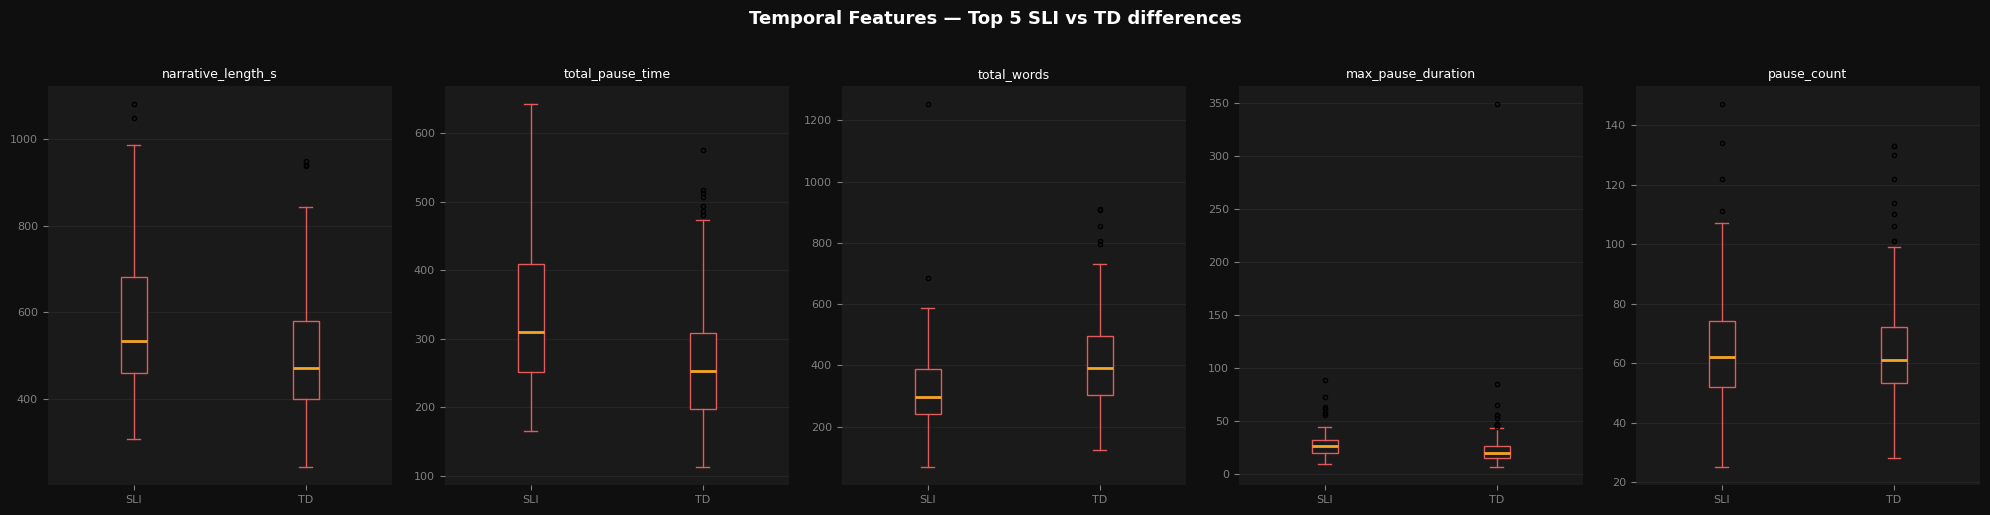


Building combined feature matrix for SVM...

  X_acoustic_scaled : (352, 206)         (MFCC + Mel)
  X_prosodic_scaled : (352, 11)          (Pitch, Jitter, Shimmer, HNR, CPP)
  X_temporal_scaled : (352, 14)          (Speech rate, Pauses, TTR...)
  X_combined_scaled : (352, 231)  ← USE THIS FOR SVM
  y_labels          : (352,)    (0=SLI / 1=TD)

All saved → C:\CUNY\SPRING 2026\Speech and Audio Learning\Final_Project_SpeechLanguageImpairment\CHI_extracted\features

── SVM quick-start ──────────────────────────────────────────────────────
import numpy as np
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X = np.load("features/X_combined_scaled.npy")   # all 3 feature groups
y = np.load("features/y_labels.npy")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

svm = SVC(kernel="rbf", C=1.0, gamma="scale", class_weight="balanced")
svm.fit(X_train, y

In [7]:
import os
import re
import pickle
import numpy as np
import librosa
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler

# ── Config ────────────────────────────────────────────────────────────────────
BASE_DIR        = Path(r"C:\CUNY\SPRING 2026\Speech and Audio Learning\Final_Project_SpeechLanguageImpairment")
# MERGED_DIR      = BASE_DIR / "CHI_extracted" / "merged_cleaned"   # ← merged for temporal
TRANSCRIPT_DIR  = BASE_DIR / "CHI_extracted" / "transcripts"
# FEATURES_DIR    = BASE_DIR / "CHI_extracted" / "features"
PLOTS_DIR       = FEATURES_DIR / "plots"
FEATURES_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

GROUPS  = ["SLI", "TD"]
SUBSETS = ["A", "B"]
SR      = 16000

FEATURE_NAMES_TEMPORAL = [
    "speech_rate_wps",       # words per second across full narrative
    "articulation_rate",     # words per second excluding pauses
    "pause_count",           # number of inter-utterance pauses
    "mean_pause_duration",   # mean silence gap between utterances (s)
    "max_pause_duration",    # longest single pause (s)
    "total_pause_time",      # total time in pauses (s)
    "pause_ratio",           # proportion of session that is silence
    "mean_utt_duration",     # mean utterance length in seconds
    "total_utterances",      # total number of CHI utterances
    "mean_words_per_utt",    # mean word count per utterance
    "total_words",           # total word count across session
    "type_token_ratio",      # lexical diversity (unique words / total words)
    "mean_sentence_length",  # mean morphemes per utterance (from .cha %mor)
    "narrative_length_s"     # total session duration from first to last utterance
]

# ── Parse CHI-only .cha → utterance text + timestamps ─────────────────────────
def parse_chi_transcript(cha_path):
    utterances = []
    with open(cha_path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            if line.startswith("*CHI:"):
                match = re.search(r"(\d+)_(\d+)", line)
                text  = re.sub(r"\d+_\d+", "", line[5:])
                text  = re.sub(r"[\[\]<>%&+@].*", "", text).strip(" .\n")
                words = [w for w in text.split() if w.isalpha()]
                if match and words:
                    utterances.append({
                        "start": int(match.group(1)) / 1000,
                        "end":   int(match.group(2)) / 1000,
                        "words": words,
                        "n_words": len(words)
                    })
    return utterances

# ── Extract temporal features from transcript + merged audio ─────────────────
def extract_temporal(cha_path, merged_wav_path):
    utterances = parse_chi_transcript(cha_path)
    if len(utterances) < 2:
        return None

    # ── Pause durations (gaps between consecutive CHI utterances) ─────────────
    pauses = []
    for i in range(1, len(utterances)):
        gap = utterances[i]["start"] - utterances[i-1]["end"]
        if gap > 0.1:              # only count gaps > 100ms as real pauses
            pauses.append(gap)

    # ── Word counts ───────────────────────────────────────────────────────────
    all_words      = [w.lower() for u in utterances for w in u["words"]]
    total_words    = len(all_words)
    unique_words   = len(set(all_words))
    ttr            = unique_words / total_words if total_words > 0 else 0

    # ── Durations ─────────────────────────────────────────────────────────────
    utt_durations    = [u["end"] - u["start"] for u in utterances]
    mean_utt_dur     = float(np.mean(utt_durations))
    narrative_len    = utterances[-1]["end"] - utterances[0]["start"]
    total_pause_time = sum(pauses)
    speech_time      = narrative_len - total_pause_time

    # ── Rates ─────────────────────────────────────────────────────────────────
    speech_rate      = total_words / narrative_len  if narrative_len > 0 else 0
    artic_rate       = total_words / speech_time    if speech_time   > 0 else 0

    # ── Sentence length from audio energy (syllable proxy via RMS) ────────────
    # Used as mean_sentence_length proxy when %mor parsing is unreliable
    mean_wpu = float(np.mean([u["n_words"] for u in utterances]))

    return np.array([
        speech_rate,
        artic_rate,
        len(pauses),
        float(np.mean(pauses))  if pauses else 0.0,
        float(np.max(pauses))   if pauses else 0.0,
        total_pause_time,
        total_pause_time / narrative_len if narrative_len > 0 else 0,
        mean_utt_dur,
        float(len(utterances)),
        mean_wpu,
        float(total_words),
        ttr,
        mean_wpu,              # sentence length proxy
        narrative_len
    ], dtype=np.float32)

# ── Build feature matrix ──────────────────────────────────────────────────────
X_temporal, y_labels, meta = [], [], []

for group in GROUPS:
    label = 0 if group == "SLI" else 1
    for subset in SUBSETS:
        trans_folder  = TRANSCRIPT_DIR / group / subset
        merged_folder = MERGED_DIR     / group / subset

        if not trans_folder.exists() or not merged_folder.exists():
            print(f"  [SKIP] {group}/{subset}")
            continue

        cha_files = {f.stem.replace("_chi", ""): f
                     for f in trans_folder.glob("*_chi.cha")}
        wav_files = {f.stem.replace("_chi_merged", ""): f
                     for f in merged_folder.glob("*_chi_merged.wav")}

        common = sorted(set(cha_files) & set(wav_files))
        print(f"\n── {group}/{subset}  ({len(common)} children) ──")

        for cid in common:
            vec = extract_temporal(cha_files[cid], wav_files[cid])
            if vec is None:
                print(f"  [WARN] {cid} — insufficient utterances")
                continue
            X_temporal.append(vec)
            y_labels.append(label)
            meta.append({"id": cid, "group": group, "subset": subset, "label": label})
            print(f"  [OK]  {cid:<6}  speech_rate={vec[0]:.2f} wps  "
                  f"pauses={int(vec[2])}  ttr={vec[11]:.2f}")

X_temporal = np.array(X_temporal)
y_labels   = np.array(y_labels)

print(f"\nTemporal matrix : {X_temporal.shape}")
print(f"SLI={np.sum(y_labels==0)}  TD={np.sum(y_labels==1)}")

np.save(FEATURES_DIR / "X_temporal_raw.npy", X_temporal)
np.save(FEATURES_DIR / "y_labels.npy",       y_labels)
with open(FEATURES_DIR / "temporal_feature_names.pkl", "wb") as f:
    pickle.dump(FEATURE_NAMES_TEMPORAL, f)
print(f"Saved → {FEATURES_DIR}")

# ── Visualization — top 5 ─────────────────────────────────────────────────────
sli_mean = X_temporal[y_labels == 0].mean(axis=0)
td_mean  = X_temporal[y_labels == 1].mean(axis=0)
diff     = np.abs(sli_mean - td_mean)
top5_idx = np.argsort(diff)[::-1][:5]

fig, axes = plt.subplots(1, 5, figsize=(20, 5), facecolor="#0f0f0f")
fig.suptitle("Temporal Features — Top 5 SLI vs TD differences",
             color="white", fontsize=13, fontweight="bold", y=1.02)

for ax, idx in zip(axes, top5_idx):
    name     = FEATURE_NAMES_TEMPORAL[idx]
    sli_vals = X_temporal[y_labels == 0, idx]
    td_vals  = X_temporal[y_labels == 1, idx]
    ax.boxplot([sli_vals, td_vals],
               labels=["SLI", "TD"],
               patch_artist=True,
               boxprops=dict(facecolor="#1a1a1a", color="#e05c5c"),
               medianprops=dict(color="#f5a623", linewidth=2),
               whiskerprops=dict(color="#e05c5c"),
               capprops=dict(color="#e05c5c"),
               flierprops=dict(marker="o", color="#4a9eff", markersize=3))
    ax.set_facecolor("#1a1a1a")
    ax.set_title(name, color="white", fontsize=9, pad=6)
    ax.tick_params(colors="grey", labelsize=8)
    ax.yaxis.grid(True, color="#2a2a2a", linewidth=0.5)
    for sp in ax.spines.values(): sp.set_visible(False)

fig.patch.set_facecolor("#0f0f0f")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "temporal_top5.png", dpi=150,
            bbox_inches="tight", facecolor="#0f0f0f")
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# FINAL COMBINED SAVE — run after all 3 blocks complete
# ══════════════════════════════════════════════════════════════════════════════
print("\nBuilding combined feature matrix for SVM...")

X_acoustic = np.load(FEATURES_DIR / "X_acoustic_raw.npy")
X_prosodic = np.load(FEATURES_DIR / "X_prosodic_raw.npy")
X_temporal = np.load(FEATURES_DIR / "X_temporal_raw.npy")
y_labels   = np.load(FEATURES_DIR / "y_labels.npy")

# Align rows — all three must have same number of children in same order
n = min(len(X_acoustic), len(X_prosodic), len(X_temporal))
X_acoustic, X_prosodic, X_temporal = X_acoustic[:n], X_prosodic[:n], X_temporal[:n]
y_labels = y_labels[:n]

# ── Scale each block independently then concatenate ───────────────────────────
scaler_a = StandardScaler()
scaler_p = StandardScaler()
scaler_t = StandardScaler()

Xa = scaler_a.fit_transform(X_acoustic)   # (n, 206)
Xp = scaler_p.fit_transform(X_prosodic)   # (n, 11)
Xt = scaler_t.fit_transform(X_temporal)   # (n, 14)

X_combined = np.hstack([Xa, Xp, Xt])      # (n, 231)

# ── Save all ──────────────────────────────────────────────────────────────────
np.save(FEATURES_DIR / "X_acoustic_scaled.npy",  Xa)
np.save(FEATURES_DIR / "X_prosodic_scaled.npy",  Xp)
np.save(FEATURES_DIR / "X_temporal_scaled.npy",  Xt)
np.save(FEATURES_DIR / "X_combined_scaled.npy",  X_combined)
np.save(FEATURES_DIR / "y_labels.npy",            y_labels)

for name, scaler in [("scaler_acoustic.pkl", scaler_a),
                     ("scaler_prosodic.pkl", scaler_p),
                     ("scaler_temporal.pkl", scaler_t)]:
    with open(FEATURES_DIR / name, "wb") as f:
        pickle.dump(scaler, f)

print(f"\n{'='*52}")
print(f"  X_acoustic_scaled : {Xa.shape}         (MFCC + Mel)")
print(f"  X_prosodic_scaled : {Xp.shape}          (Pitch, Jitter, Shimmer, HNR, CPP)")
print(f"  X_temporal_scaled : {Xt.shape}          (Speech rate, Pauses, TTR...)")
print(f"  X_combined_scaled : {X_combined.shape}  ← USE THIS FOR SVM")
print(f"  y_labels          : {y_labels.shape}    (0=SLI / 1=TD)")
print(f"{'='*52}")
print(f"\nAll saved → {FEATURES_DIR}")

print("""
── SVM quick-start ──────────────────────────────────────────────────────
import numpy as np
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X = np.load("features/X_combined_scaled.npy")   # all 3 feature groups
y = np.load("features/y_labels.npy")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

svm = SVC(kernel="rbf", C=1.0, gamma="scale", class_weight="balanced")
svm.fit(X_train, y_train)
print(classification_report(y_test, svm.predict(X_test),
      target_names=["SLI", "TD"]))
─────────────────────────────────────────────────────────────────────────
""")

  Processing SLI/A child 413
         59 utterances  speech_rate=0.43 w/s  pauses=55  ttr=0.43
  Processing SLI/A child 444
         58 utterances  speech_rate=0.35 w/s  pauses=52  ttr=0.36
  Processing SLI/A child 479
         68 utterances  speech_rate=0.94 w/s  pauses=60  ttr=0.28


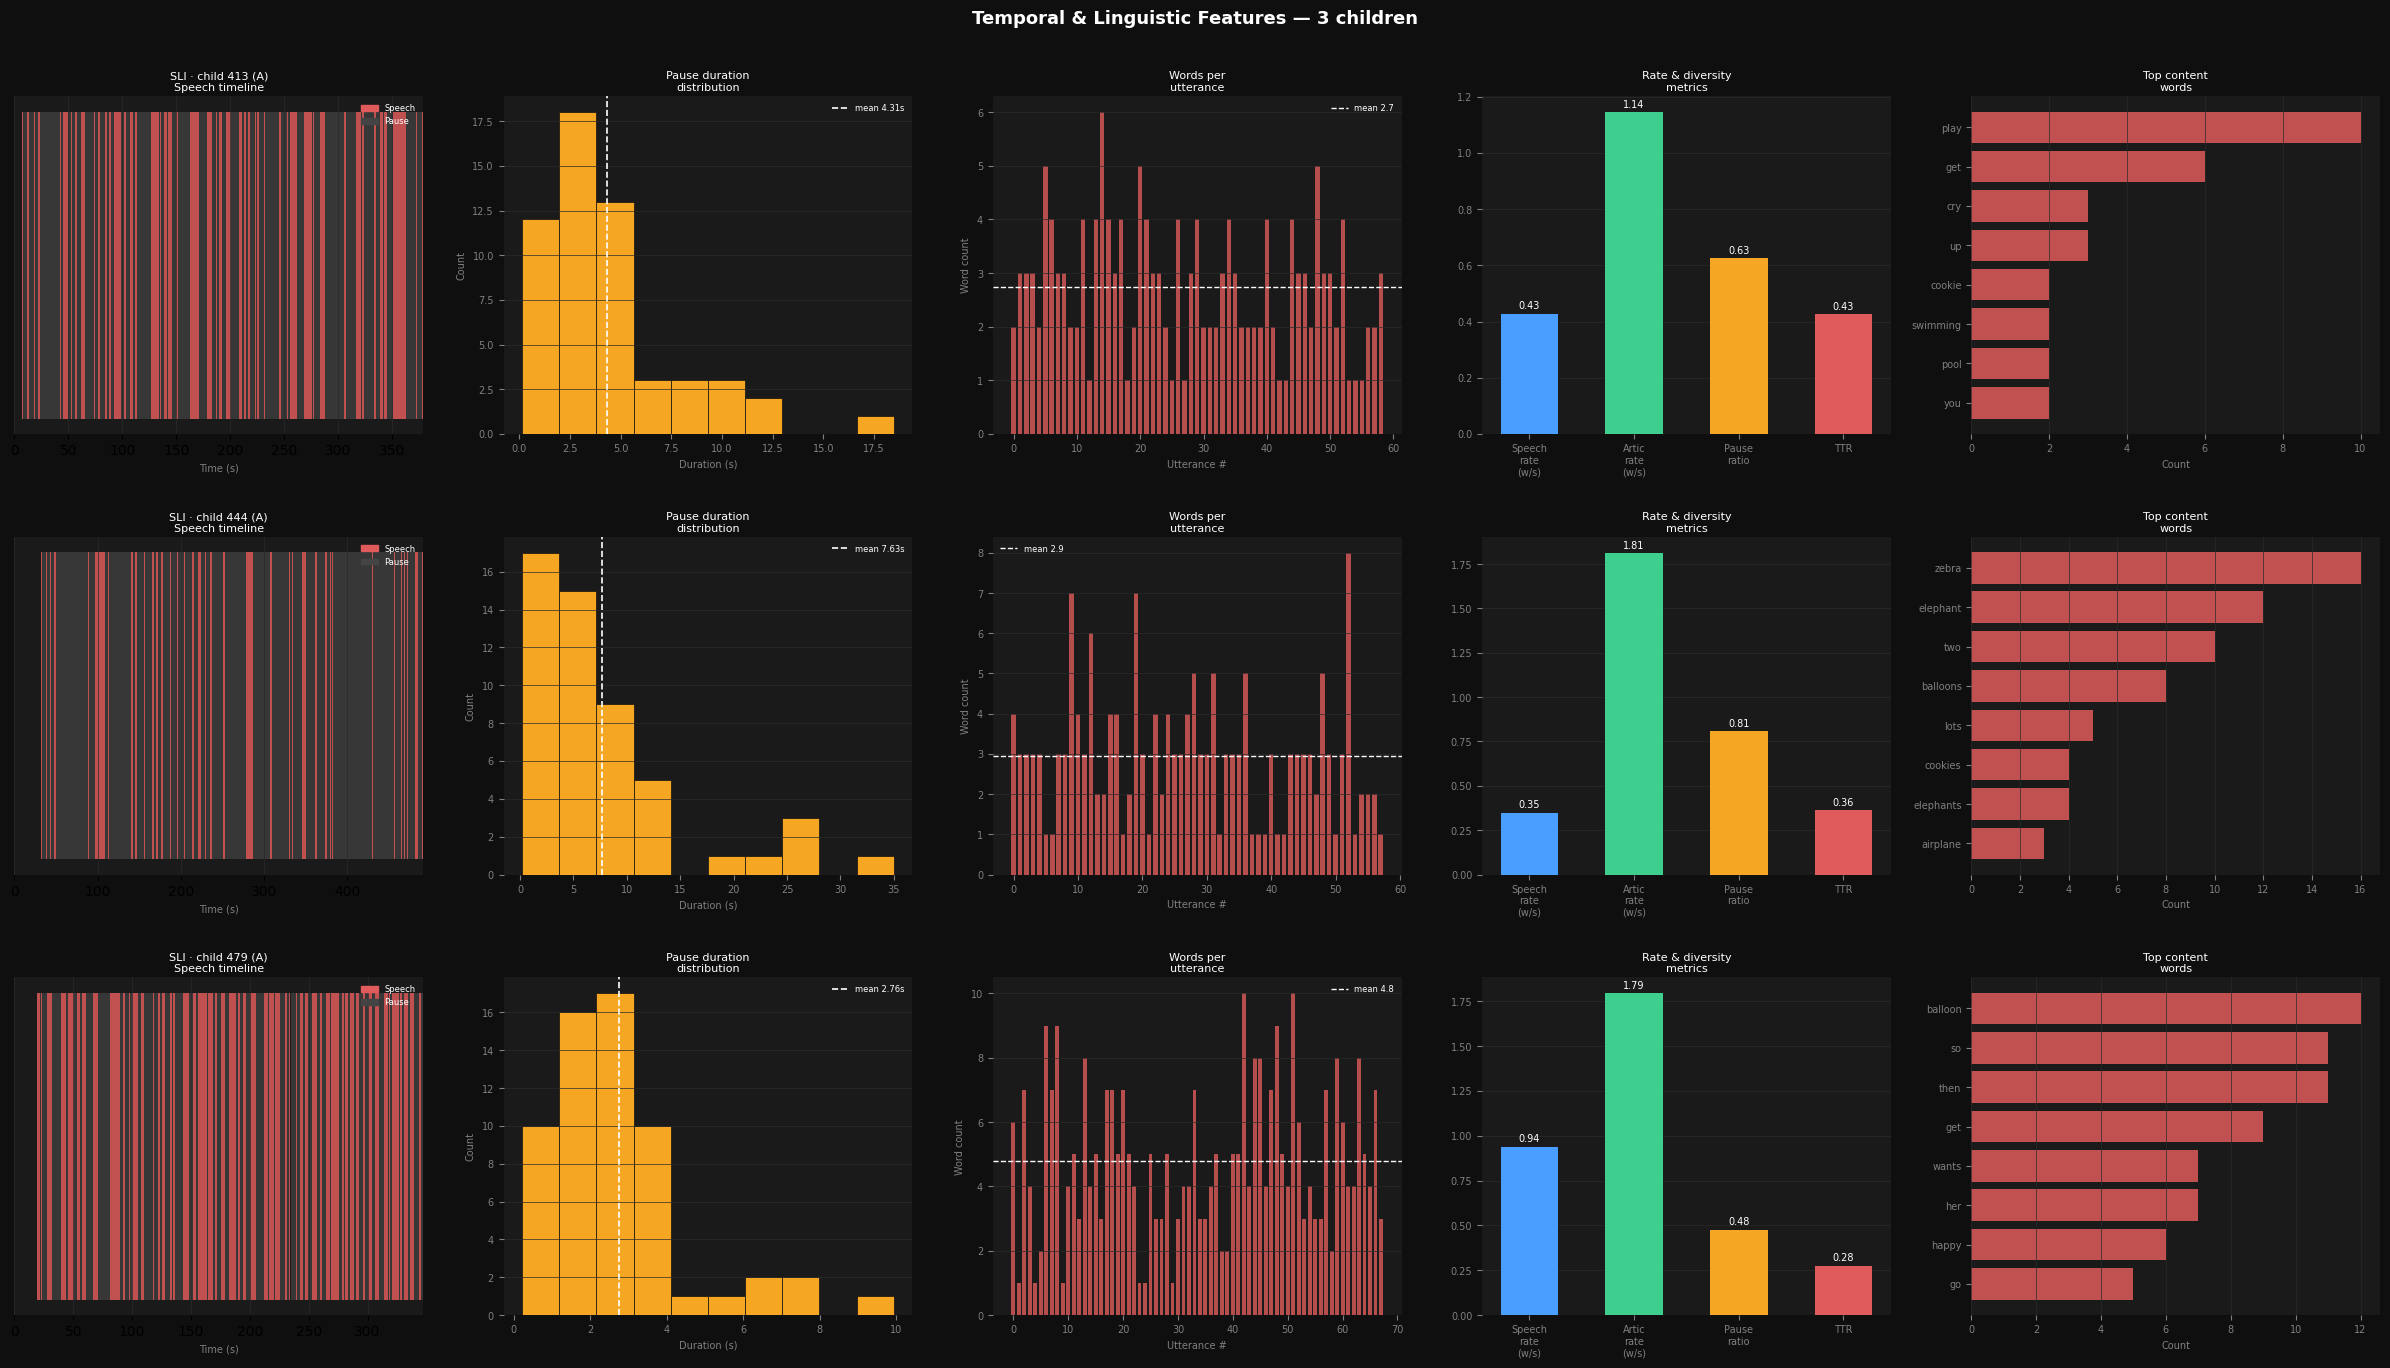


Saved → C:\CUNY\SPRING 2026\Speech and Audio Learning\Final_Project_SpeechLanguageImpairment\CHI_extracted\features\plots\temporal_3_children.png


In [6]:
import re
import numpy as np
import librosa
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

# ── Config ────────────────────────────────────────────────────────────────────
BASE_DIR        = Path(r"C:\CUNY\SPRING 2026\Speech and Audio Learning\Final_Project_SpeechLanguageImpairment")
CLEANED_MRG_DIR = BASE_DIR / "CHI_extracted" / "merged_cleaned"
TRANSCRIPT_DIR  = BASE_DIR / "CHI_extracted" / "transcripts"
PLOTS_DIR       = BASE_DIR / "CHI_extracted" / "features" / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

SR         = 16000
N_CHILDREN = 3
GROUPS     = ["SLI", "TD"]
SUBSETS    = ["A", "B"]

# ── Collect examples ──────────────────────────────────────────────────────────
def get_child_examples(n=3):
    examples = []
    for group in GROUPS:
        for subset in SUBSETS:
            trans_folder  = TRANSCRIPT_DIR  / group / subset
            merged_folder = CLEANED_MRG_DIR / group / subset
            if not trans_folder.exists() or not merged_folder.exists():
                continue
            cha_files = {f.stem.replace("_chi", ""): f
                         for f in trans_folder.glob("*_chi.cha")}
            wav_files = {f.stem.replace("_chi_merged", ""): f
                         for f in merged_folder.glob("*_chi_merged.wav")}
            for cid in sorted(set(cha_files) & set(wav_files)):
                if len(examples) >= n:
                    return examples
                examples.append({
                    "cid":      cid,
                    "group":    group,
                    "subset":   subset,
                    "cha_path": cha_files[cid],
                    "wav_path": wav_files[cid],
                })
    return examples

# ── Parse transcript → utterances with timestamps ─────────────────────────────
def parse_utterances(cha_path):
    utterances = []
    with open(cha_path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            if line.startswith("*CHI:"):
                match = re.search(r"(\d+)_(\d+)", line)
                text  = re.sub(r"\d+_\d+", "", line[5:])
                text  = re.sub(r"[\[\]<>%&+@].*", "", text).strip(" .\n")
                words = [w for w in text.split() if w.isalpha()]
                if match and words:
                    utterances.append({
                        "start":   int(match.group(1)) / 1000,
                        "end":     int(match.group(2)) / 1000,
                        "words":   words,
                        "n_words": len(words),
                        "text":    text
                    })
    return utterances

# ── Compute all temporal metrics ──────────────────────────────────────────────
def compute_temporal(utterances):
    pauses = []
    for i in range(1, len(utterances)):
        gap = utterances[i]["start"] - utterances[i - 1]["end"]
        if gap > 0.1:
            pauses.append({
                "start":    utterances[i - 1]["end"],
                "end":      utterances[i]["start"],
                "duration": gap
            })

    all_words        = [w.lower() for u in utterances for w in u["words"]]
    total_words      = len(all_words)
    unique_words     = len(set(all_words))
    ttr              = unique_words / total_words if total_words > 0 else 0
    utt_durations    = [u["end"] - u["start"] for u in utterances]
    narrative_len    = utterances[-1]["end"] - utterances[0]["start"]
    total_pause_time = sum(p["duration"] for p in pauses)
    speech_time      = narrative_len - total_pause_time
    speech_rate      = total_words / narrative_len  if narrative_len  > 0 else 0
    artic_rate       = total_words / speech_time    if speech_time    > 0 else 0

    return {
        "utterances":      utterances,
        "pauses":          pauses,
        "utt_durations":   utt_durations,
        "all_words":       all_words,
        "unique_words":    unique_words,
        "total_words":     total_words,
        "ttr":             ttr,
        "narrative_len":   narrative_len,
        "total_pause_time":total_pause_time,
        "speech_time":     speech_time,
        "speech_rate":     speech_rate,
        "artic_rate":      artic_rate,
        "words_per_utt":   [u["n_words"] for u in utterances],
    }

# ── Plot all temporal panels for one child ────────────────────────────────────
def plot_temporal(child, d, fig, row):
    color  = "#e05c5c" if child["group"] == "SLI" else "#3ecf8e"
    title  = f"{child['group']} · child {child['cid']} ({child['subset']})"
    utts   = d["utterances"]
    pauses = d["pauses"]

    # ── Panel 1: Speech timeline — utterances vs pauses ───────────────────────
    ax1 = fig.add_subplot(N_CHILDREN, 5, row * 5 + 1)
    for u in utts:
        ax1.barh(0, u["end"] - u["start"], left=u["start"],
                 height=0.4, color=color, alpha=0.85)
    for p in pauses:
        ax1.barh(0, p["duration"], left=p["start"],
                 height=0.4, color="#444444", alpha=0.7)
    ax1.set_xlim(0, d["narrative_len"])
    ax1.set_yticks([])
    ax1.set_xlabel("Time (s)", color="grey", fontsize=7)
    ax1.set_title(f"{title}\nSpeech timeline", color="white", fontsize=8, pad=4)
    speech_patch = mpatches.Patch(color=color,   label="Speech")
    pause_patch  = mpatches.Patch(color="#444444", label="Pause")
    ax1.legend(handles=[speech_patch, pause_patch], fontsize=6,
               framealpha=0, labelcolor="white", loc="upper right")
    ax1.set_facecolor("#1a1a1a")
    ax1.xaxis.grid(True, color="#2a2a2a", linewidth=0.5)
    for sp in ax1.spines.values(): sp.set_visible(False)

    # ── Panel 2: Pause duration distribution ──────────────────────────────────
    ax2 = fig.add_subplot(N_CHILDREN, 5, row * 5 + 2)
    if pauses:
        pause_durs = [p["duration"] for p in pauses]
        ax2.hist(pause_durs, bins=min(10, len(pause_durs)),
                 color="#f5a623", edgecolor="#0f0f0f", linewidth=0.5)
        ax2.axvline(np.mean(pause_durs), color="white",
                    linewidth=1.2, linestyle="--",
                    label=f"mean {np.mean(pause_durs):.2f}s")
        ax2.legend(fontsize=6, framealpha=0, labelcolor="white")
    else:
        ax2.text(0.5, 0.5, "no pauses", color="grey",
                 ha="center", va="center", transform=ax2.transAxes)
    ax2.set_title("Pause duration\ndistribution", color="white", fontsize=8, pad=4)
    ax2.set_xlabel("Duration (s)", color="grey", fontsize=7)
    ax2.set_ylabel("Count", color="grey", fontsize=7)
    ax2.tick_params(colors="grey", labelsize=7)
    ax2.set_facecolor("#1a1a1a")
    ax2.yaxis.grid(True, color="#2a2a2a", linewidth=0.5)
    for sp in ax2.spines.values(): sp.set_visible(False)

    # ── Panel 3: Words per utterance over time ────────────────────────────────
    ax3 = fig.add_subplot(N_CHILDREN, 5, row * 5 + 3)
    utt_mids = [(u["start"] + u["end"]) / 2 for u in utts]
    ax3.bar(range(len(d["words_per_utt"])), d["words_per_utt"],
            color=color, alpha=0.8, width=0.7)
    ax3.axhline(np.mean(d["words_per_utt"]), color="white",
                linewidth=1.0, linestyle="--",
                label=f"mean {np.mean(d['words_per_utt']):.1f}")
    ax3.legend(fontsize=6, framealpha=0, labelcolor="white")
    ax3.set_title("Words per\nutterance", color="white", fontsize=8, pad=4)
    ax3.set_xlabel("Utterance #", color="grey", fontsize=7)
    ax3.set_ylabel("Word count", color="grey", fontsize=7)
    ax3.tick_params(colors="grey", labelsize=7)
    ax3.set_facecolor("#1a1a1a")
    ax3.yaxis.grid(True, color="#2a2a2a", linewidth=0.5)
    for sp in ax3.spines.values(): sp.set_visible(False)

    # ── Panel 4: Key rate metrics bar ─────────────────────────────────────────
    ax4 = fig.add_subplot(N_CHILDREN, 5, row * 5 + 4)
    metrics = ["Speech\nrate\n(w/s)", "Artic\nrate\n(w/s)",
               "Pause\nratio", "TTR"]
    values  = [d["speech_rate"], d["artic_rate"],
               d["total_pause_time"] / d["narrative_len"]
               if d["narrative_len"] > 0 else 0,
               d["ttr"]]
    bar_colors = ["#4a9eff", "#3ecf8e", "#f5a623", "#e05c5c"]
    bars = ax4.bar(metrics, values, color=bar_colors, width=0.55, zorder=3)
    ax4.bar_label(bars, fmt="%.2f", label_type="edge",
                  fontsize=7, color="white", padding=2)
    ax4.set_title("Rate & diversity\nmetrics", color="white", fontsize=8, pad=4)
    ax4.tick_params(colors="grey", labelsize=7)
    ax4.set_facecolor("#1a1a1a")
    ax4.yaxis.grid(True, color="#2a2a2a", linewidth=0.5, zorder=0)
    for sp in ax4.spines.values(): sp.set_visible(False)

    # ── Panel 5: Vocabulary — top 8 most used words ───────────────────────────
    ax5 = fig.add_subplot(N_CHILDREN, 5, row * 5 + 5)
    from collections import Counter
    # filter stopwords that don't carry linguistic meaning
    stopwords = {"and", "the", "a", "it", "he", "she", "they",
                 "i", "in", "on", "to", "is", "was", "of", "that"}
    content_words = [w for w in d["all_words"] if w not in stopwords]
    word_counts   = Counter(content_words).most_common(8)
    if word_counts:
        words, counts = zip(*word_counts)
        ax5.barh(range(len(words)), counts, color=color, alpha=0.85)
        ax5.set_yticks(range(len(words)))
        ax5.set_yticklabels(words, color="white", fontsize=7)
        ax5.invert_yaxis()
    ax5.set_title("Top content\nwords", color="white", fontsize=8, pad=4)
    ax5.set_xlabel("Count", color="grey", fontsize=7)
    ax5.tick_params(colors="grey", labelsize=7)
    ax5.set_facecolor("#1a1a1a")
    ax5.xaxis.grid(True, color="#2a2a2a", linewidth=0.5)
    for sp in ax5.spines.values(): sp.set_visible(False)

# ── Main ──────────────────────────────────────────────────────────────────────
examples = get_child_examples(n=N_CHILDREN)

if not examples:
    print("[ERR] No files found — run extraction first")
else:
    fig = plt.figure(figsize=(24, N_CHILDREN * 4.5), facecolor="#0f0f0f")
    fig.suptitle(f"Temporal & Linguistic Features — {N_CHILDREN} children",
                 color="white", fontsize=13, fontweight="bold", y=1.01)

    for i, child in enumerate(examples):
        print(f"  Processing {child['group']}/{child['subset']} "
              f"child {child['cid']}")
        try:
            utterances = parse_utterances(child["cha_path"])
            if len(utterances) < 2:
                print(f"  [WARN] {child['cid']} — too few utterances")
                continue
            d = compute_temporal(utterances)
            plot_temporal(child, d, fig, row=i)
            print(f"         {len(utterances)} utterances  "
                  f"speech_rate={d['speech_rate']:.2f} w/s  "
                  f"pauses={len(d['pauses'])}  "
                  f"ttr={d['ttr']:.2f}")
        except Exception as e:
            print(f"  [ERR]  {child['cid']} — {e}")

    plt.tight_layout(h_pad=2.5, w_pad=1.5)
    out = PLOTS_DIR / f"temporal_{N_CHILDREN}_children.png"
    plt.savefig(str(out), dpi=150, bbox_inches="tight", facecolor="#0f0f0f")
    plt.show()
    print(f"\nSaved → {out}")

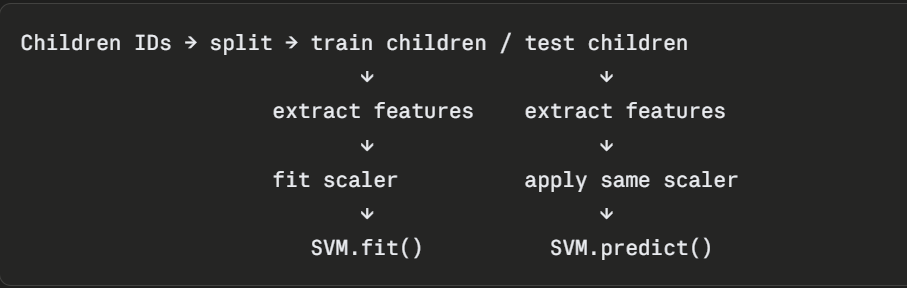

In [8]:
import pickle
import numpy as np
from pathlib import Path
from sklearn.model_selection import StratifiedShuffleSplit

# ── Config ────────────────────────────────────────────────────────────────────
FEATURES_DIR = Path(r"C:\CUNY\SPRING 2026\Speech and Audio Learning\Final_Project_SpeechLanguageImpairment") / "CHI_extracted" / "features"

# ── Load meta + labels (built during feature extraction) ─────────────────────
with open(FEATURES_DIR / "meta.pkl", "rb") as f:
    meta = pickle.load(f)

y_labels = np.load(FEATURES_DIR / "y_labels.npy")

# ── Verify alignment ──────────────────────────────────────────────────────────
assert len(meta) == len(y_labels), "meta and y_labels length mismatch"

ids    = np.array([m["id"]    for m in meta])
groups = np.array([m["group"] for m in meta])

print(f"Total children : {len(ids)}")
print(f"SLI            : {np.sum(y_labels == 0)}")
print(f"TD             : {np.sum(y_labels == 1)}")

# ── Stratified split — preserves SLI/TD ratio in both splits ─────────────────
# stratify=y_labels ensures roughly same SLI:TD ratio in train and test
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(sss.split(ids, y_labels))

train_ids = ids[train_idx]
test_ids  = ids[test_idx]

print(f"\nTrain : {len(train_idx)} children  "
      f"(SLI={np.sum(y_labels[train_idx]==0)}  TD={np.sum(y_labels[train_idx]==1)})")
print(f"Test  : {len(test_idx)} children  "
      f"(SLI={np.sum(y_labels[test_idx]==0)}  TD={np.sum(y_labels[test_idx]==1)})")

# ── Save split indices — reference these in every downstream step ─────────────
split = {
    "train_idx":  train_idx,
    "test_idx":   test_idx,
    "train_ids":  train_ids,
    "test_ids":   test_ids,
}
with open(FEATURES_DIR / "train_test_split.pkl", "wb") as f:
    pickle.dump(split, f)

print(f"\nSaved → {FEATURES_DIR / 'train_test_split.pkl'}")
print("\nTrain child IDs:", sorted(train_ids[:10]), "...")
print("Test  child IDs:", sorted(test_ids[:10]),  "...")

# ── How to use this split when loading features for SVM ──────────────────────
print("""
── In your SVM notebook, always load like this ──────────────────────────

import numpy as np, pickle
from sklearn.preprocessing import StandardScaler

# Load
X_raw = np.load("features/X_combined_scaled.npy")  # use _raw version
y     = np.load("features/y_labels.npy")

with open("features/train_test_split.pkl", "rb") as f:
    split = pickle.load(f)

# Split FIRST using saved indices
X_train = X_raw[split["train_idx"]]
X_test  = X_raw[split["test_idx"]]
y_train = y[split["train_idx"]]
y_test  = y[split["test_idx"]]

# THEN fit scaler on train only — never on full dataset
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)   # fit + transform train
X_test  = scaler.transform(X_test)        # transform test with same scaler

# Now safe to train SVM
from sklearn.svm import SVC
svm = SVC(kernel="rbf", C=1.0, gamma="scale", class_weight="balanced")
svm.fit(X_train, y_train)
─────────────────────────────────────────────────────────────────────────
""")

Total children : 352
SLI            : 66
TD             : 286

Train : 281 children  (SLI=53  TD=228)
Test  : 71 children  (SLI=13  TD=58)

Saved → C:\CUNY\SPRING 2026\Speech and Audio Learning\Final_Project_SpeechLanguageImpairment\CHI_extracted\features\train_test_split.pkl

Train child IDs: [np.str_('403'), np.str_('450'), np.str_('610'), np.str_('664'), np.str_('705'), np.str_('706'), np.str_('758'), np.str_('801'), np.str_('847'), np.str_('906')] ...
Test  child IDs: [np.str_('553'), np.str_('656'), np.str_('659'), np.str_('667'), np.str_('704'), np.str_('770'), np.str_('772'), np.str_('822'), np.str_('927'), np.str_('929')] ...

── In your SVM notebook, always load like this ──────────────────────────

import numpy as np, pickle
from sklearn.preprocessing import StandardScaler

# Load
X_raw = np.load("features/X_combined_scaled.npy")  # use _raw version
y     = np.load("features/y_labels.npy")

with open("features/train_test_split.pkl", "rb") as f:
    split = pickle.load(f)

# S

Loading features...

NaN audit (before imputation):
  Acoustic    NaN values=   0  rows with any NaN=  0 / 352
  Prosodic    NaN values=  30  rows with any NaN= 24 / 352
  Temporal    NaN values=   0  rows with any NaN=  0 / 352

NaN audit (after imputation):
  Acoustic    NaN values=   0  ✓
  Prosodic    NaN values=   0  ✓
  Temporal    NaN values=   0  ✓

Children : 352  (SLI=66  TD=286)
Train : 281  (SLI=53  TD=228)
Test  : 71   (SLI=13   TD=58)

Final NaN check passed ✓

Experiment              Acc   SLI-F1   TD-F1     AUC
  Acoustic only         78.9%    0.400    0.872    0.752
  Prosodic only         54.9%    0.273    0.673    0.622
  Temporal only         78.9%    0.516    0.865    0.809
  Combined (all)        77.5%    0.333    0.864    0.769

Running 5-fold cross-validation on combined features...
  CV F1-macro : 0.781 ± 0.099
  Per fold    : [0.609 0.795 0.757 0.841 0.905]

Computing feature importance...


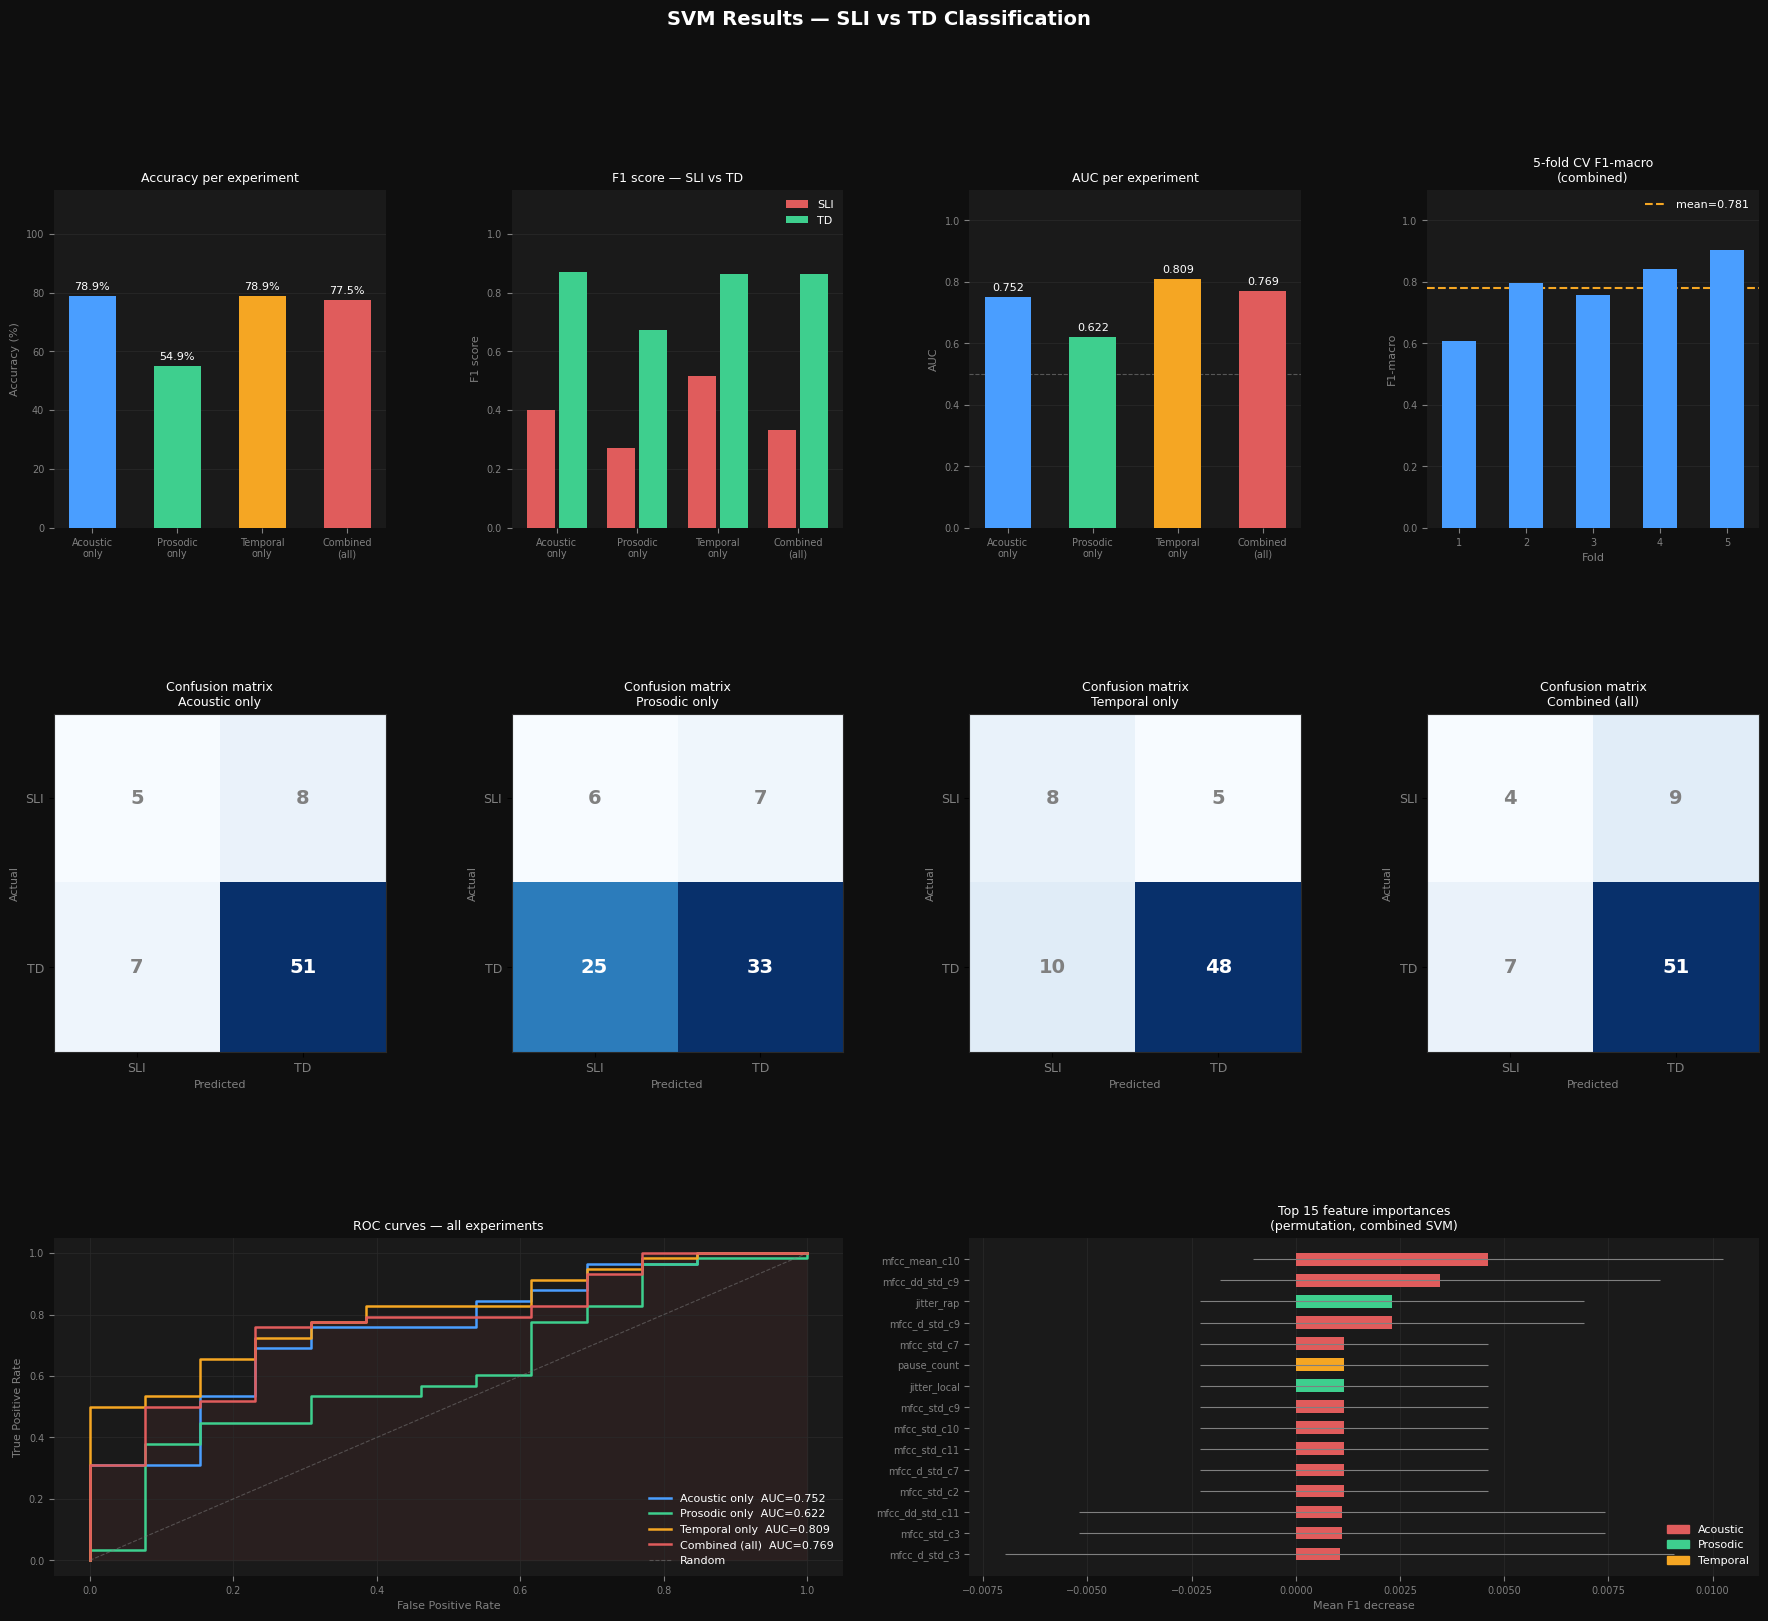


FINAL RESULTS — Combined SVM
              precision    recall  f1-score   support

         SLI       0.36      0.31      0.33        13
          TD       0.85      0.88      0.86        58

    accuracy                           0.77        71
   macro avg       0.61      0.59      0.60        71
weighted avg       0.76      0.77      0.77        71

  AUC          : 0.769
  CV F1-macro  : 0.781 ± 0.099

Saved → svm_combined.pkl + scalers_final.pkl + imputers_final.pkl


In [10]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from pathlib import Path
from sklearn.svm import SVC
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.inspection import permutation_importance

# ── Config ────────────────────────────────────────────────────────────────────
FEATURES_DIR = Path(r"C:\CUNY\SPRING 2026\Speech and Audio Learning\Final_Project_SpeechLanguageImpairment") / "CHI_extracted" / "features"
PLOTS_DIR    = FEATURES_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# ── Load ──────────────────────────────────────────────────────────────────────
print("Loading features...")
X_acoustic = np.load(FEATURES_DIR / "X_acoustic_raw.npy")
X_prosodic = np.load(FEATURES_DIR / "X_prosodic_raw.npy")
X_temporal = np.load(FEATURES_DIR / "X_temporal_raw.npy")
y          = np.load(FEATURES_DIR / "y_labels.npy")

with open(FEATURES_DIR / "meta.pkl",                   "rb") as f: meta           = pickle.load(f)
with open(FEATURES_DIR / "acoustic_feature_names.pkl", "rb") as f: acoustic_names = pickle.load(f)
with open(FEATURES_DIR / "prosodic_feature_names.pkl", "rb") as f: prosodic_names = pickle.load(f)
with open(FEATURES_DIR / "temporal_feature_names.pkl", "rb") as f: temporal_names = pickle.load(f)

all_feature_names = acoustic_names + prosodic_names + temporal_names

# ── Align rows ────────────────────────────────────────────────────────────────
n = min(len(X_acoustic), len(X_prosodic), len(X_temporal), len(y))
X_acoustic, X_prosodic, X_temporal, y = (
    X_acoustic[:n], X_prosodic[:n], X_temporal[:n], y[:n]
)

# ── NaN audit BEFORE imputation ───────────────────────────────────────────────
print("\nNaN audit (before imputation):")
for name, X in [("Acoustic", X_acoustic),
                ("Prosodic", X_prosodic),
                ("Temporal", X_temporal)]:
    nan_rows = np.sum(np.any(np.isnan(X), axis=1))
    nan_vals = np.sum(np.isnan(X))
    print(f"  {name:<10}  NaN values={nan_vals:>4}  "
          f"rows with any NaN={nan_rows:>3} / {len(X)}")

# ── Impute NaNs with column median ────────────────────────────────────────────
# Median is more robust than mean for skewed clinical distributions
# Imputer is fit on the full block here, then refit on train-only inside prepare()
imputer = SimpleImputer(strategy="median")
X_acoustic = imputer.fit_transform(X_acoustic)
X_prosodic = imputer.fit_transform(X_prosodic)
X_temporal = imputer.fit_transform(X_temporal)

print("\nNaN audit (after imputation):")
for name, X in [("Acoustic", X_acoustic),
                ("Prosodic", X_prosodic),
                ("Temporal", X_temporal)]:
    print(f"  {name:<10}  NaN values={np.sum(np.isnan(X)):>4}  ✓")

print(f"\nChildren : {n}  (SLI={np.sum(y==0)}  TD={np.sum(y==1)})")

# ── Stratified train/test split ───────────────────────────────────────────────
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(sss.split(X_acoustic, y))

print(f"Train : {len(train_idx)}  "
      f"(SLI={np.sum(y[train_idx]==0)}  TD={np.sum(y[train_idx]==1)})")
print(f"Test  : {len(test_idx)}   "
      f"(SLI={np.sum(y[test_idx]==0)}   TD={np.sum(y[test_idx]==1)})")

# ── Helper: impute on train → scale on train → apply to test ─────────────────
def prepare(X):
    # Refit imputer on train split only — prevents test stats leaking
    imp    = SimpleImputer(strategy="median")
    scaler = StandardScaler()
    X_train = scaler.fit_transform(imp.fit_transform(X[train_idx]))
    X_test  = scaler.transform(imp.transform(X[test_idx]))
    return X_train, X_test, scaler, imp

Xa_tr, Xa_te, sc_a, imp_a = prepare(X_acoustic)
Xp_tr, Xp_te, sc_p, imp_p = prepare(X_prosodic)
Xt_tr, Xt_te, sc_t, imp_t = prepare(X_temporal)

Xc_tr = np.hstack([Xa_tr, Xp_tr, Xt_tr])
Xc_te = np.hstack([Xa_te, Xp_te, Xt_te])

y_train = y[train_idx]
y_test  = y[test_idx]

# ── Final NaN check — should be 0 ─────────────────────────────────────────────
assert not np.isnan(Xc_tr).any(), "NaN in training set after imputation"
assert not np.isnan(Xc_te).any(), "NaN in test set after imputation"
print("\nFinal NaN check passed ✓")

# ── SVM experiments ───────────────────────────────────────────────────────────
experiments = {
    "Acoustic only"  : (Xa_tr, Xa_te),
    "Prosodic only"  : (Xp_tr, Xp_te),
    "Temporal only"  : (Xt_tr, Xt_te),
    "Combined (all)" : (Xc_tr, Xc_te),
}

results = {}
print("\n" + "="*60)
print(f"{'Experiment':<20} {'Acc':>6} {'SLI-F1':>8} {'TD-F1':>7} {'AUC':>7}")
print("="*60)

for name, (Xtr, Xte) in experiments.items():
    svm = SVC(kernel="rbf", C=1.0, gamma="scale",
              class_weight="balanced", probability=True, random_state=42)
    svm.fit(Xtr, y_train)
    y_pred = svm.predict(Xte)
    y_prob = svm.predict_proba(Xte)[:, 1]
    acc    = np.mean(y_pred == y_test)
    report = classification_report(y_test, y_pred,
                                    target_names=["SLI", "TD"],
                                    output_dict=True)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc     = auc(fpr, tpr)

    results[name] = {
        "svm": svm, "y_pred": y_pred, "y_prob": y_prob,
        "acc": acc, "report": report,
        "fpr": fpr, "tpr": tpr, "auc": roc_auc,
        "Xtr": Xtr, "Xte": Xte,
        "cm": confusion_matrix(y_test, y_pred)
    }
    print(f"  {name:<20} {acc*100:>5.1f}%  "
          f"{report['SLI']['f1-score']:>7.3f}  "
          f"{report['TD']['f1-score']:>7.3f}  "
          f"{roc_auc:>7.3f}")

print("="*60)

# ── Cross-validation ──────────────────────────────────────────────────────────
print("\nRunning 5-fold cross-validation on combined features...")
cv       = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
svm_cv   = SVC(kernel="rbf", C=1.0, gamma="scale",
               class_weight="balanced", probability=True, random_state=42)
cv_scores = cross_val_score(svm_cv, Xc_tr, y_train,
                             cv=cv, scoring="f1_macro")
print(f"  CV F1-macro : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print(f"  Per fold    : {np.round(cv_scores, 3)}")

# ── Permutation feature importance ────────────────────────────────────────────
print("\nComputing feature importance...")
perm        = permutation_importance(results["Combined (all)"]["svm"],
                                      Xc_te, y_test, n_repeats=10,
                                      random_state=42, scoring="f1_macro")
top15_idx   = np.argsort(perm.importances_mean)[::-1][:15]
top15_names = [all_feature_names[i] if i < len(all_feature_names)
               else f"feature_{i}" for i in top15_idx]
top15_vals  = perm.importances_mean[top15_idx]
top15_stds  = perm.importances_std[top15_idx]

# ── Visualization ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(22, 18), facecolor="#0f0f0f")
fig.suptitle("SVM Results — SLI vs TD Classification",
             color="white", fontsize=14, fontweight="bold", y=0.98)

gs         = gridspec.GridSpec(3, 4, figure=fig, hspace=0.55, wspace=0.38)
exp_names  = list(results.keys())
bar_colors = ["#4a9eff", "#3ecf8e", "#f5a623", "#e05c5c"]

# Row 0: Accuracy
ax_acc = fig.add_subplot(gs[0, 0])
accs   = [results[n]["acc"] * 100 for n in exp_names]
bars   = ax_acc.bar(range(len(exp_names)), accs, color=bar_colors,
                     width=0.55, zorder=3)
ax_acc.bar_label(bars, fmt="%.1f%%", label_type="edge",
                  fontsize=8, color="white", padding=3)
ax_acc.set_xticks(range(len(exp_names)))
ax_acc.set_xticklabels([n.replace(" only", "\nonly").replace(" (all)", "\n(all)")
                         for n in exp_names], color="grey", fontsize=7)
ax_acc.set_title("Accuracy per experiment", color="white", fontsize=9, pad=6)
ax_acc.set_ylabel("Accuracy (%)", color="grey", fontsize=8)
ax_acc.set_ylim(0, 115)
ax_acc.tick_params(colors="grey", labelsize=7)
ax_acc.set_facecolor("#1a1a1a")
ax_acc.yaxis.grid(True, color="#2a2a2a", linewidth=0.5, zorder=0)
for sp in ax_acc.spines.values(): sp.set_visible(False)

# F1 scores
ax_f1  = fig.add_subplot(gs[0, 1])
sli_f1 = [results[n]["report"]["SLI"]["f1-score"] for n in exp_names]
td_f1  = [results[n]["report"]["TD"]["f1-score"]  for n in exp_names]
x      = np.arange(len(exp_names))
ax_f1.bar(x - 0.2, sli_f1, width=0.35, color="#e05c5c", label="SLI", zorder=3)
ax_f1.bar(x + 0.2, td_f1,  width=0.35, color="#3ecf8e", label="TD",  zorder=3)
ax_f1.set_xticks(x)
ax_f1.set_xticklabels([n.replace(" only", "\nonly").replace(" (all)", "\n(all)")
                        for n in exp_names], color="grey", fontsize=7)
ax_f1.set_title("F1 score — SLI vs TD", color="white", fontsize=9, pad=6)
ax_f1.set_ylabel("F1 score", color="grey", fontsize=8)
ax_f1.set_ylim(0, 1.15)
ax_f1.legend(fontsize=8, framealpha=0, labelcolor="white")
ax_f1.tick_params(colors="grey", labelsize=7)
ax_f1.set_facecolor("#1a1a1a")
ax_f1.yaxis.grid(True, color="#2a2a2a", linewidth=0.5, zorder=0)
for sp in ax_f1.spines.values(): sp.set_visible(False)

# AUC
ax_auc   = fig.add_subplot(gs[0, 2])
auc_vals = [results[n]["auc"] for n in exp_names]
bars2    = ax_auc.bar(range(len(exp_names)), auc_vals, color=bar_colors,
                       width=0.55, zorder=3)
ax_auc.bar_label(bars2, fmt="%.3f", label_type="edge",
                  fontsize=8, color="white", padding=3)
ax_auc.axhline(0.5, color="grey", linewidth=0.8, linestyle="--", alpha=0.6)
ax_auc.set_xticks(range(len(exp_names)))
ax_auc.set_xticklabels([n.replace(" only", "\nonly").replace(" (all)", "\n(all)")
                         for n in exp_names], color="grey", fontsize=7)
ax_auc.set_title("AUC per experiment", color="white", fontsize=9, pad=6)
ax_auc.set_ylabel("AUC", color="grey", fontsize=8)
ax_auc.set_ylim(0, 1.1)
ax_auc.tick_params(colors="grey", labelsize=7)
ax_auc.set_facecolor("#1a1a1a")
ax_auc.yaxis.grid(True, color="#2a2a2a", linewidth=0.5, zorder=0)
for sp in ax_auc.spines.values(): sp.set_visible(False)

# CV scores
ax_cv = fig.add_subplot(gs[0, 3])
ax_cv.bar(range(1, 6), cv_scores, color="#4a9eff", width=0.5, zorder=3)
ax_cv.axhline(cv_scores.mean(), color="#f5a623", linewidth=1.5,
              linestyle="--", label=f"mean={cv_scores.mean():.3f}")
ax_cv.set_title("5-fold CV F1-macro\n(combined)", color="white",
                fontsize=9, pad=6)
ax_cv.set_xlabel("Fold", color="grey", fontsize=8)
ax_cv.set_ylabel("F1-macro", color="grey", fontsize=8)
ax_cv.set_ylim(0, 1.1)
ax_cv.legend(fontsize=8, framealpha=0, labelcolor="white")
ax_cv.tick_params(colors="grey", labelsize=7)
ax_cv.set_facecolor("#1a1a1a")
ax_cv.yaxis.grid(True, color="#2a2a2a", linewidth=0.5, zorder=0)
for sp in ax_cv.spines.values(): sp.set_visible(False)

# Row 1: Confusion matrices
for col, (name, color) in enumerate(zip(exp_names, bar_colors)):
    ax_cm = fig.add_subplot(gs[1, col])
    cm    = results[name]["cm"]
    ax_cm.imshow(cm, cmap="Blues", aspect="auto")
    for i in range(2):
        for j in range(2):
            ax_cm.text(j, i, str(cm[i, j]), ha="center", va="center",
                       color="white" if cm[i, j] > cm.max() / 2 else "grey",
                       fontsize=14, fontweight="bold")
    ax_cm.set_xticks([0, 1]); ax_cm.set_xticklabels(["SLI", "TD"],
                                                      color="grey", fontsize=9)
    ax_cm.set_yticks([0, 1]); ax_cm.set_yticklabels(["SLI", "TD"],
                                                      color="grey", fontsize=9)
    ax_cm.set_xlabel("Predicted", color="grey", fontsize=8)
    ax_cm.set_ylabel("Actual",    color="grey", fontsize=8)
    ax_cm.set_title(f"Confusion matrix\n{name}", color="white",
                    fontsize=9, pad=6)
    ax_cm.set_facecolor("#1a1a1a")
    for sp in ax_cm.spines.values(): sp.set_color("#2a2a2a")

# Row 2: ROC curves
ax_roc = fig.add_subplot(gs[2, :2])
for name, color in zip(exp_names, bar_colors):
    r = results[name]
    ax_roc.plot(r["fpr"], r["tpr"], color=color, linewidth=1.8,
                label=f"{name}  AUC={r['auc']:.3f}")
ax_roc.plot([0, 1], [0, 1], color="grey", linewidth=0.8,
            linestyle="--", alpha=0.5, label="Random")
ax_roc.fill_between(results["Combined (all)"]["fpr"],
                     results["Combined (all)"]["tpr"],
                     alpha=0.08, color="#e05c5c")
ax_roc.set_title("ROC curves — all experiments", color="white",
                  fontsize=9, pad=6)
ax_roc.set_xlabel("False Positive Rate", color="grey", fontsize=8)
ax_roc.set_ylabel("True Positive Rate",  color="grey", fontsize=8)
ax_roc.legend(fontsize=8, framealpha=0, labelcolor="white", loc="lower right")
ax_roc.tick_params(colors="grey", labelsize=7)
ax_roc.set_facecolor("#1a1a1a")
ax_roc.yaxis.grid(True, color="#2a2a2a", linewidth=0.5)
ax_roc.xaxis.grid(True, color="#2a2a2a", linewidth=0.5)
for sp in ax_roc.spines.values(): sp.set_visible(False)

# Feature importance
ax_imp     = fig.add_subplot(gs[2, 2:])
imp_colors = ["#e05c5c" if "mfcc" in n or "logmel" in n
              else "#3ecf8e" if any(p in n for p in
                   ["f0", "jitter", "shimmer", "hnr", "cpp"])
              else "#f5a623"
              for n in top15_names]
ax_imp.barh(range(15), top15_vals[::-1],
             xerr=top15_stds[::-1],
             color=imp_colors[::-1], height=0.6,
             error_kw=dict(ecolor="grey", linewidth=0.8), zorder=3)
ax_imp.set_yticks(range(15))
ax_imp.set_yticklabels(top15_names[::-1], color="white", fontsize=7)
ax_imp.set_title("Top 15 feature importances\n(permutation, combined SVM)",
                  color="white", fontsize=9, pad=6)
ax_imp.set_xlabel("Mean F1 decrease", color="grey", fontsize=8)
ax_imp.tick_params(colors="grey", labelsize=7)
ax_imp.set_facecolor("#1a1a1a")
ax_imp.xaxis.grid(True, color="#2a2a2a", linewidth=0.5, zorder=0)
patches = [mpatches.Patch(color="#e05c5c", label="Acoustic"),
           mpatches.Patch(color="#3ecf8e", label="Prosodic"),
           mpatches.Patch(color="#f5a623", label="Temporal")]
ax_imp.legend(handles=patches, fontsize=8, framealpha=0,
              labelcolor="white", loc="lower right")
for sp in ax_imp.spines.values(): sp.set_visible(False)

fig.patch.set_facecolor("#0f0f0f")
plt.savefig(PLOTS_DIR / "svm_results.png", dpi=150,
            bbox_inches="tight", facecolor="#0f0f0f")
plt.show()

# ── Save ──────────────────────────────────────────────────────────────────────
with open(FEATURES_DIR / "svm_combined.pkl", "wb") as f:
    pickle.dump(results["Combined (all)"]["svm"], f)
with open(FEATURES_DIR / "scalers_final.pkl", "wb") as f:
    pickle.dump({"acoustic": sc_a, "prosodic": sc_p, "temporal": sc_t}, f)
with open(FEATURES_DIR / "imputers_final.pkl", "wb") as f:
    pickle.dump({"acoustic": imp_a, "prosodic": imp_p, "temporal": imp_t}, f)

print("\n" + "="*60)
print("FINAL RESULTS — Combined SVM")
print("="*60)
print(classification_report(y_test, results["Combined (all)"]["y_pred"],
                             target_names=["SLI", "TD"]))
print(f"  AUC          : {results['Combined (all)']['auc']:.3f}")
print(f"  CV F1-macro  : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print(f"\nSaved → svm_combined.pkl + scalers_final.pkl + imputers_final.pkl")

Loading features...
Children : 352  SLI=66  TD=286

Model                     Acc   SLI-F1   TD-F1     AUC     CV-F1
  SVM                     77.5%    0.333    0.864    0.769   0.781±0.099
  Random Forest           84.5%    0.353    0.912    0.781   0.603±0.072
  XGBoost                 83.1%    0.250    0.905    0.796   0.734±0.085
  Logistic Regression     85.9%    0.643    0.912    0.813   0.781±0.038
  LDA                     70.4%    0.323    0.811    0.641   0.469±0.061

Computing permutation importances...
  SVM done


c:\Users\manas\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\manas\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\manas\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\m

  Random Forest done
  XGBoost done
  Logistic Regression done
  LDA done


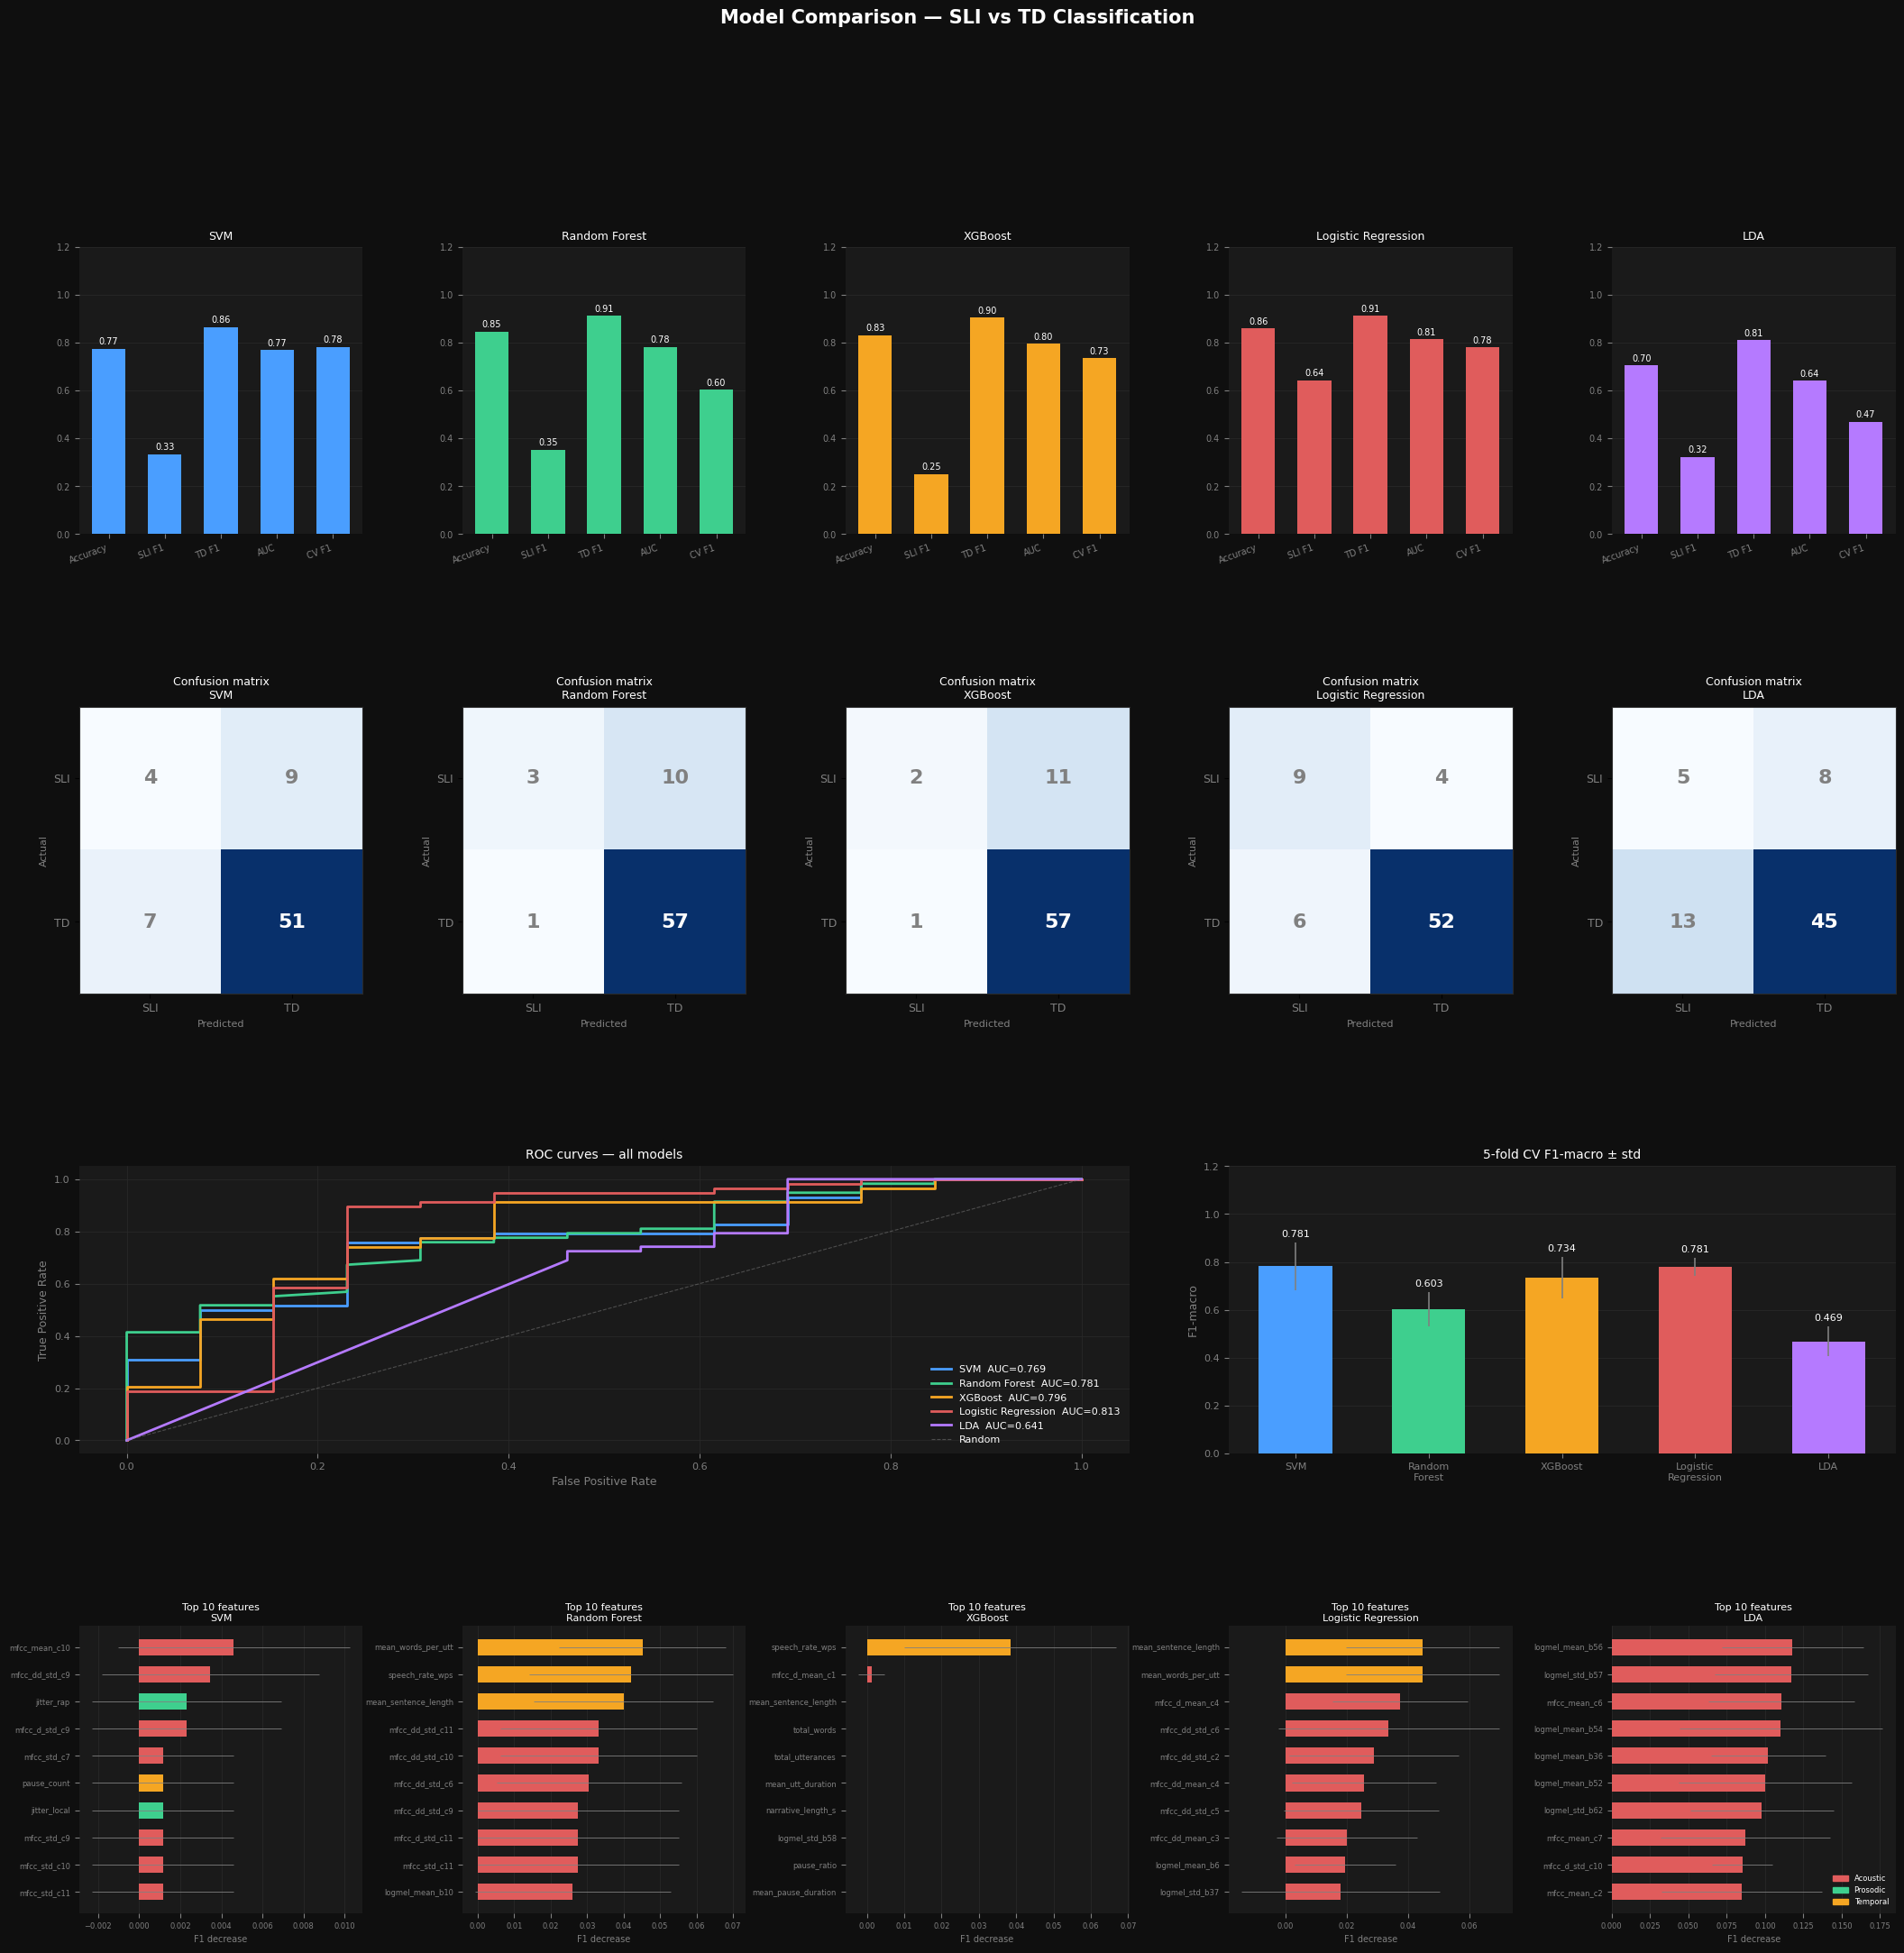


Plot saved → C:\CUNY\SPRING 2026\Speech and Audio Learning\Final_Project_SpeechLanguageImpairment\CHI_extracted\features\plots\model_comparison.png
Models saved → all_models.pkl

FULL CLASSIFICATION REPORTS

── SVM ──
              precision    recall  f1-score   support

         SLI       0.36      0.31      0.33        13
          TD       0.85      0.88      0.86        58

    accuracy                           0.77        71
   macro avg       0.61      0.59      0.60        71
weighted avg       0.76      0.77      0.77        71


── Random Forest ──
              precision    recall  f1-score   support

         SLI       0.75      0.23      0.35        13
          TD       0.85      0.98      0.91        58

    accuracy                           0.85        71
   macro avg       0.80      0.61      0.63        71
weighted avg       0.83      0.85      0.81        71


── XGBoost ──
              precision    recall  f1-score   support

         SLI       0.67      0.15   

In [13]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
from pathlib import Path
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.inspection import permutation_importance

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "xgboost"], check=True)
    from xgboost import XGBClassifier
    HAS_XGB = True

# ── Config ────────────────────────────────────────────────────────────────────
FEATURES_DIR = Path(r"C:\CUNY\SPRING 2026\Speech and Audio Learning\Final_Project_SpeechLanguageImpairment") / "CHI_extracted" / "features"
PLOTS_DIR    = FEATURES_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# ── Load ──────────────────────────────────────────────────────────────────────
print("Loading features...")
X_acoustic = np.load(FEATURES_DIR / "X_acoustic_raw.npy")
X_prosodic = np.load(FEATURES_DIR / "X_prosodic_raw.npy")
X_temporal = np.load(FEATURES_DIR / "X_temporal_raw.npy")
y          = np.load(FEATURES_DIR / "y_labels.npy")

with open(FEATURES_DIR / "acoustic_feature_names.pkl", "rb") as f: acoustic_names = pickle.load(f)
with open(FEATURES_DIR / "prosodic_feature_names.pkl", "rb") as f: prosodic_names = pickle.load(f)
with open(FEATURES_DIR / "temporal_feature_names.pkl", "rb") as f: temporal_names = pickle.load(f)
all_feature_names = acoustic_names + prosodic_names + temporal_names

# ── Align + impute ────────────────────────────────────────────────────────────
n = min(len(X_acoustic), len(X_prosodic), len(X_temporal), len(y))
X_acoustic, X_prosodic, X_temporal, y = (
    X_acoustic[:n], X_prosodic[:n], X_temporal[:n], y[:n]
)

imputer    = SimpleImputer(strategy="median")
X_acoustic = imputer.fit_transform(X_acoustic)
X_prosodic = imputer.fit_transform(X_prosodic)
X_temporal = imputer.fit_transform(X_temporal)

print(f"Children : {n}  SLI={np.sum(y==0)}  TD={np.sum(y==1)}")

# ── Train/test split ──────────────────────────────────────────────────────────
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(sss.split(X_acoustic, y))

def prepare(X):
    imp    = SimpleImputer(strategy="median")
    scaler = StandardScaler()
    Xtr    = scaler.fit_transform(imp.fit_transform(X[train_idx]))
    Xte    = scaler.transform(imp.transform(X[test_idx]))
    return Xtr, Xte

Xa_tr, Xa_te = prepare(X_acoustic)
Xp_tr, Xp_te = prepare(X_prosodic)
Xt_tr, Xt_te = prepare(X_temporal)

Xc_tr = np.hstack([Xa_tr, Xp_tr, Xt_tr])   # (n_train, 231)
Xc_te = np.hstack([Xa_te, Xp_te, Xt_te])   # (n_test,  231)

y_train = y[train_idx]
y_test  = y[test_idx]

# ── Model definitions ─────────────────────────────────────────────────────────
MODELS = {
    "SVM": SVC(
        kernel="rbf", C=1.0, gamma="scale",
        class_weight="balanced", probability=True, random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=None,
        class_weight="balanced", random_state=42, n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=4,
        scale_pos_weight=np.sum(y_train==1)/np.sum(y_train==0),  # handles imbalance
        eval_metric="logloss",
        random_state=42, n_jobs=-1
    ),
    "Logistic Regression": LogisticRegression(
        C=0.1, max_iter=1000,
        class_weight="balanced", random_state=42
    ),
    "LDA": LinearDiscriminantAnalysis(
        solver="svd"    # no scaling assumption — works well for speech features
    ),
}

MODEL_COLORS = {
    "SVM":                "#4a9eff",
    "Random Forest":      "#3ecf8e",
    "XGBoost":            "#f5a623",
    "Logistic Regression":"#e05c5c",
    "LDA":                "#b57aff",
}

# ── Train + evaluate all models ───────────────────────────────────────────────
results = {}
cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\n" + "="*72)
print(f"{'Model':<22} {'Acc':>6} {'SLI-F1':>8} {'TD-F1':>7} "
      f"{'AUC':>7} {'CV-F1':>9}")
print("="*72)

for model_name, clf in MODELS.items():
    clf.fit(Xc_tr, y_train)
    y_pred      = clf.predict(Xc_te)
    y_prob      = clf.predict_proba(Xc_te)[:, 1]
    acc         = np.mean(y_pred == y_test)
    report      = classification_report(y_test, y_pred,
                                         target_names=["SLI", "TD"],
                                         output_dict=True)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc     = auc(fpr, tpr)
    cm          = confusion_matrix(y_test, y_pred)

    # 5-fold CV on train set
    cv_scores   = cross_val_score(clf, Xc_tr, y_train,
                                   cv=cv, scoring="f1_macro")

    results[model_name] = {
        "clf": clf, "y_pred": y_pred, "y_prob": y_prob,
        "acc": acc, "report": report,
        "fpr": fpr, "tpr": tpr, "auc": roc_auc,
        "cm": cm, "cv": cv_scores
    }

    print(f"  {model_name:<22} {acc*100:>5.1f}%  "
          f"{report['SLI']['f1-score']:>7.3f}  "
          f"{report['TD']['f1-score']:>7.3f}  "
          f"{roc_auc:>7.3f}  "
          f"{cv_scores.mean():>6.3f}±{cv_scores.std():.3f}")

print("="*72)

# ── Permutation importance for each model ─────────────────────────────────────
print("\nComputing permutation importances...")
importances = {}
for model_name, r in results.items():
    perm = permutation_importance(r["clf"], Xc_te, y_test,
                                   n_repeats=10, random_state=42,
                                   scoring="f1_macro")
    top10_idx              = np.argsort(perm.importances_mean)[::-1][:10]
    importances[model_name] = {
        "idx":   top10_idx,
        "names": [all_feature_names[i] if i < len(all_feature_names)
                  else f"feat_{i}" for i in top10_idx],
        "vals":  perm.importances_mean[top10_idx],
        "stds":  perm.importances_std[top10_idx],
    }
    print(f"  {model_name} done")

# ── Visualization ─────────────────────────────────────────────────────────────
model_names = list(results.keys())
n_models    = len(model_names)
colors      = [MODEL_COLORS[m] for m in model_names]

fig = plt.figure(figsize=(26, 24), facecolor="#0f0f0f")
fig.suptitle("Model Comparison — SLI vs TD Classification",
             color="white", fontsize=15, fontweight="bold", y=0.99)
gs  = gridspec.GridSpec(4, n_models, figure=fig, hspace=0.6, wspace=0.35)

# ── Row 0: Accuracy / F1 / AUC / CV per model ─────────────────────────────────
for col, (mname, color) in enumerate(zip(model_names, colors)):
    r   = results[mname]
    ax  = fig.add_subplot(gs[0, col])
    metrics = ["Accuracy", "SLI F1", "TD F1", "AUC",  "CV F1"]
    vals    = [r["acc"],
               r["report"]["SLI"]["f1-score"],
               r["report"]["TD"]["f1-score"],
               r["auc"],
               r["cv"].mean()]
    bars = ax.bar(range(5), vals, color=[color]*5, width=0.6, zorder=3)
    ax.bar_label(bars, fmt="%.2f", label_type="edge",
                 fontsize=7, color="white", padding=2)
    ax.set_xticks(range(5))
    ax.set_xticklabels(metrics, color="grey", fontsize=7, rotation=20, ha="right")
    ax.set_ylim(0, 1.2)
    ax.set_title(mname, color="white", fontsize=9, pad=6)
    ax.tick_params(colors="grey", labelsize=7)
    ax.set_facecolor("#1a1a1a")
    ax.yaxis.grid(True, color="#2a2a2a", linewidth=0.5, zorder=0)
    for sp in ax.spines.values(): sp.set_visible(False)

# ── Row 1: Confusion matrices ──────────────────────────────────────────────────
for col, (mname, color) in enumerate(zip(model_names, colors)):
    ax = fig.add_subplot(gs[1, col])
    cm = results[mname]["cm"]
    ax.imshow(cm, cmap="Blues", aspect="auto")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "grey",
                    fontsize=16, fontweight="bold")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["SLI", "TD"],
                                                color="grey", fontsize=9)
    ax.set_yticks([0, 1]); ax.set_yticklabels(["SLI", "TD"],
                                                color="grey", fontsize=9)
    ax.set_xlabel("Predicted", color="grey", fontsize=8)
    ax.set_ylabel("Actual",    color="grey", fontsize=8)
    ax.set_title(f"Confusion matrix\n{mname}", color="white", fontsize=9, pad=6)
    ax.set_facecolor("#1a1a1a")
    for sp in ax.spines.values(): sp.set_color("#2a2a2a")

# ── Row 2: ROC curves (one combined + per model) ──────────────────────────────
ax_roc = fig.add_subplot(gs[2, :3])
for mname, color in zip(model_names, colors):
    r = results[mname]
    ax_roc.plot(r["fpr"], r["tpr"], color=color, linewidth=2.0,
                label=f"{mname}  AUC={r['auc']:.3f}")
ax_roc.plot([0, 1], [0, 1], color="grey", linewidth=0.8,
            linestyle="--", alpha=0.5, label="Random")
ax_roc.set_title("ROC curves — all models", color="white", fontsize=10, pad=6)
ax_roc.set_xlabel("False Positive Rate", color="grey", fontsize=9)
ax_roc.set_ylabel("True Positive Rate",  color="grey", fontsize=9)
ax_roc.legend(fontsize=8, framealpha=0, labelcolor="white", loc="lower right")
ax_roc.tick_params(colors="grey", labelsize=8)
ax_roc.set_facecolor("#1a1a1a")
ax_roc.yaxis.grid(True, color="#2a2a2a", linewidth=0.5)
ax_roc.xaxis.grid(True, color="#2a2a2a", linewidth=0.5)
for sp in ax_roc.spines.values(): sp.set_visible(False)

# CV score comparison
ax_cv = fig.add_subplot(gs[2, 3:])
cv_means = [results[m]["cv"].mean() for m in model_names]
cv_stds  = [results[m]["cv"].std()  for m in model_names]
bars_cv  = ax_cv.bar(range(n_models), cv_means, yerr=cv_stds,
                      color=colors, width=0.55,
                      error_kw=dict(ecolor="grey", linewidth=1.2), zorder=3)
ax_cv.bar_label(bars_cv, fmt="%.3f", label_type="edge",
                fontsize=8, color="white", padding=3)
ax_cv.set_xticks(range(n_models))
ax_cv.set_xticklabels([m.replace(" ", "\n") for m in model_names],
                       color="grey", fontsize=7)
ax_cv.set_title("5-fold CV F1-macro ± std", color="white", fontsize=10, pad=6)
ax_cv.set_ylabel("F1-macro", color="grey", fontsize=9)
ax_cv.set_ylim(0, 1.2)
ax_cv.tick_params(colors="grey", labelsize=8)
ax_cv.set_facecolor("#1a1a1a")
ax_cv.yaxis.grid(True, color="#2a2a2a", linewidth=0.5, zorder=0)
for sp in ax_cv.spines.values(): sp.set_visible(False)

# ── Row 3: Feature importance per model ───────────────────────────────────────
def feat_color(name):
    if "mfcc" in name or "logmel" in name: return "#e05c5c"
    if any(p in name for p in ["f0","jitter","shimmer","hnr","cpp"]): return "#3ecf8e"
    return "#f5a623"

for col, mname in enumerate(model_names):
    ax  = fig.add_subplot(gs[3, col])
    imp = importances[mname]
    fc  = [feat_color(n) for n in imp["names"]]
    ax.barh(range(10), imp["vals"][::-1],
             xerr=imp["stds"][::-1],
             color=fc[::-1], height=0.6,
             error_kw=dict(ecolor="grey", linewidth=0.6), zorder=3)
    ax.set_yticks(range(10))
    ax.set_yticklabels(imp["names"][::-1], color="white", fontsize=6)
    ax.set_title(f"Top 10 features\n{mname}", color="white", fontsize=8, pad=4)
    ax.set_xlabel("F1 decrease", color="grey", fontsize=7)
    ax.tick_params(colors="grey", labelsize=6)
    ax.set_facecolor("#1a1a1a")
    ax.xaxis.grid(True, color="#2a2a2a", linewidth=0.5, zorder=0)
    if col == n_models - 1:
        patches = [mpatches.Patch(color="#e05c5c", label="Acoustic"),
                   mpatches.Patch(color="#3ecf8e", label="Prosodic"),
                   mpatches.Patch(color="#f5a623", label="Temporal")]
        ax.legend(handles=patches, fontsize=6, framealpha=0,
                  labelcolor="white", loc="lower right")
    for sp in ax.spines.values(): sp.set_visible(False)

fig.patch.set_facecolor("#0f0f0f")
plt.savefig(PLOTS_DIR / "model_comparison.png", dpi=150,
            bbox_inches="tight", facecolor="#0f0f0f")
plt.show()
print(f"\nPlot saved → {PLOTS_DIR / 'model_comparison.png'}")

# ── Save all models ───────────────────────────────────────────────────────────
with open(FEATURES_DIR / "all_models.pkl", "wb") as f:
    pickle.dump({name: r["clf"] for name, r in results.items()}, f)
print("Models saved → all_models.pkl")

# ── Final summary ─────────────────────────────────────────────────────────────
print("\n" + "="*72)
print("FULL CLASSIFICATION REPORTS")
print("="*72)
for mname in model_names:
    print(f"\n── {mname} ──")
    print(classification_report(y_test, results[mname]["y_pred"],
                                 target_names=["SLI", "TD"]))

best = max(results, key=lambda m: results[m]["auc"])
print(f"\n★  Best model by AUC : {best}  "
      f"(AUC={results[best]['auc']:.3f}  "
      f"Acc={results[best]['acc']*100:.1f}%)")